In [1]:
# DermaVision AI – Module 1

## Model 1: ANN/MLP-Based Skin Disease Classification

### Dataset: PAD-UFES-20

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load the PAD-UFES-20 dataset

file_path = "../dataset/PAD_UFES_20/metadata.csv"

df = pd.read_csv(file_path)

# Display the first 5 rows
df.head()

,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [4]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display all column names
print("\nColumn names:")
print(df.columns.tolist())

# Check data types
print("\nData types:")
print(df.dtypes)

Dataset shape: (2298, 26)

Column names:
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Data types:
patient_id                 str
lesion_id                int64
smoke                   object
drink                   object
background_father          str
background_mother          str
age                      int64
pesticide               object
gender                     str
skin_cancer_history     object
cancer_history          object
has_piped_water         object
has_sewage_system       object
fitspatrick            float64
region                     str
diameter_1             float64
diameter_2             float64
diagnostic                 str
itch                       str
grew         

In [5]:
# Check missing values in each column
print("Missing values:")
print(df.isnull().sum())

# Check the number of unique diagnosis classes
print("\nDiagnosis classes:")
print(df["diagnostic"].value_counts())

# Total number of unique classes
print("\nNumber of diagnosis classes:")
print(df["diagnostic"].nunique())

Missing values:
patient_id               0
lesion_id                0
smoke                  804
drink                  804
background_father      818
background_mother      822
age                      0
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
fitspatrick            804
region                   0
diameter_1             804
diameter_2             804
diagnostic               0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed                    0
elevation                0
img_id                   0
biopsed                  0
dtype: int64

Diagnosis classes:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

Number of diagnosis classes:
6


In [6]:
# Create a copy of the dataset for preprocessing

data = df.copy()

# Remove identifier columns
columns_to_drop = ["patient_id", "lesion_id", "img_id"]

data = data.drop(columns=columns_to_drop)

# Check the new dataset shape
print("New dataset shape:", data.shape)

# Display the first 5 rows
data.head()

New dataset shape: (2298, 23)


,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,cancer_history,has_piped_water,...,diameter_1,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,biopsed
0,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NEV,False,False,False,False,False,False,False
1,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,True,True,...,6.0,5.0,BCC,True,True,False,True,True,True,True
2,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ACK,True,False,False,False,False,False,False
3,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ACK,True,False,False,False,False,False,False
4,False,True,POMERANIA,POMERANIA,79,False,MALE,True,False,False,...,5.0,5.0,BCC,True,True,False,False,True,True,True


In [7]:
# Separate numerical and categorical columns

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_columns = data.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

# Remove the target column from categorical features
categorical_features = [
    column for column in categorical_columns
    if column != "diagnostic"
]

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical/Boolean feature columns:")
print(categorical_features)

Numerical columns:
['age', 'fitspatrick', 'diameter_1', 'diameter_2']

Categorical/Boolean feature columns:
['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']


C:\Users\Sourya Dey\AppData\Local\Temp\ipykernel_15828\4078899100.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(


In [8]:
# Fill missing values in numerical columns with the median

for column in numerical_columns:
    data[column] = data[column].fillna(data[column].median())


# Fill missing values in categorical columns with the most frequent value

for column in categorical_features:
    data[column] = data[column].fillna(data[column].mode()[0])


# Check if any missing values remain
print("Total missing values remaining:", data.isnull().sum().sum())

Total missing values remaining: 0


In [9]:
# Separate input features and target

X = data.drop("diagnostic", axis=1)
y = data["diagnostic"]


# Convert categorical features into numerical format
X = pd.get_dummies(X, columns=categorical_features, dtype=int)


# Display the new shape
print("Feature dataset shape:", X.shape)

# Display first 5 rows
X.head()

Feature dataset shape: (2298, 78)


,age,fitspatrick,diameter_1,diameter_2,smoke_False,smoke_True,drink_False,drink_True,background_father_AUSTRIA,background_father_BRASIL,...,changed_True,changed_UNK,bleed_False,bleed_True,bleed_UNK,elevation_False,elevation_True,elevation_UNK,biopsed_False,biopsed_True
0,8,2.0,10.0,8.0,1,0,1,0,0,0,...,0,0,1,0,0,1,0,0,1,0
1,55,3.0,6.0,5.0,1,0,1,0,0,0,...,1,0,0,1,0,0,1,0,0,1
2,77,2.0,10.0,8.0,1,0,1,0,0,0,...,0,0,1,0,0,1,0,0,1,0
3,75,2.0,10.0,8.0,1,0,1,0,0,0,...,0,0,1,0,0,1,0,0,1,0
4,79,1.0,5.0,5.0,1,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1


In [10]:
from sklearn.preprocessing import LabelEncoder

# Create the label encoder
label_encoder = LabelEncoder()

# Convert diagnosis names into numerical labels
y_encoded = label_encoder.fit_transform(y)

# Display the class mapping
for index, class_name in enumerate(label_encoder.classes_):
    print(index, "=", class_name)

0 = ACK
1 = BCC
2 = MEL
3 = NEV
4 = SCC
5 = SEK


In [11]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training samples: 1838
Testing samples: 460

Training feature shape: (1838, 78)
Testing feature shape: (460, 78)


In [12]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Columns that need scaling
numerical_features = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

# Fit only on training data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

# Use the same scaler for test data
X_test_scaled[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

print("Scaling completed successfully.")
print("\nScaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaling completed successfully.

Scaled training data shape: (1838, 78)
Scaled testing data shape: (460, 78)


In [13]:
# Convert DataFrames to NumPy arrays

X_train_final = X_train_scaled.to_numpy(dtype=np.float32)
X_test_final = X_test_scaled.to_numpy(dtype=np.float32)

y_train_final = np.array(y_train, dtype=np.int64)
y_test_final = np.array(y_test, dtype=np.int64)

print("X_train shape:", X_train_final.shape)
print("X_test shape:", X_test_final.shape)
print("y_train shape:", y_train_final.shape)
print("y_test shape:", y_test_final.shape)

X_train shape: (1838, 78)
X_test shape: (460, 78)
y_train shape: (1838,)
y_test shape: (460,)


In [14]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cpu
CUDA available: False


In [15]:
import random
import numpy as np
import torch

# Set a fixed seed for reproducible results
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Improve reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed set successfully:", SEED)

Random seed set successfully: 42


In [16]:
import torch.nn as nn

# Define the ANN model
class SkinDiseaseANN(nn.Module):
    
    def __init__(self, input_size, num_classes):
        super(SkinDiseaseANN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.network(x)


# Create the model
input_size = X_train_final.shape[1]
num_classes = len(label_encoder.classes_)

model = SkinDiseaseANN(input_size, num_classes)

print(model)

SkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [17]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001


In [18]:
# Convert NumPy arrays to PyTorch tensors

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_final, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_final, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_final, dtype=torch.long)

print("Training tensor shape:", X_train_tensor.shape)
print("Testing tensor shape:", X_test_tensor.shape)

Training tensor shape: torch.Size([1838, 78])
Testing tensor shape: torch.Size([460, 78])


In [19]:
from torch.utils.data import TensorDataset, DataLoader

# Create training and testing datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

# Batch size
batch_size = 32

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 58
Testing batches: 15


In [20]:
# Number of training epochs
epochs = 100

# Lists to store training history
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    
    # Set model to training mode
    model.train()
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # Process each batch
    for inputs, labels in train_loader:
        
        # Reset previous gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backpropagation
        loss.backward()
        
        # Update weights and biases
        optimizer.step()
        
        # Store loss
        running_loss += loss.item() * inputs.size(0)
        
        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)
        
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()
    
    # Calculate average loss and accuracy
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    
    # Save history
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Loss: {epoch_loss:.4f} | "
            f"Accuracy: {epoch_accuracy:.4f}"
        )

Epoch [1/100] | Loss: 1.4404 | Accuracy: 0.5196
Epoch [10/100] | Loss: 0.5841 | Accuracy: 0.7878
Epoch [20/100] | Loss: 0.4825 | Accuracy: 0.8205
Epoch [30/100] | Loss: 0.3898 | Accuracy: 0.8607
Epoch [40/100] | Loss: 0.3364 | Accuracy: 0.8868
Epoch [50/100] | Loss: 0.2748 | Accuracy: 0.9010
Epoch [60/100] | Loss: 0.2465 | Accuracy: 0.9119
Epoch [70/100] | Loss: 0.2159 | Accuracy: 0.9233
Epoch [80/100] | Loss: 0.1896 | Accuracy: 0.9271
Epoch [90/100] | Loss: 0.1747 | Accuracy: 0.9363
Epoch [100/100] | Loss: 0.1655 | Accuracy: 0.9418


In [ ]:
# Evaluate the model on the unseen test dataset

model.eval()

correct_predictions = 0
total_samples = 0
test_loss = 0.0

with torch.no_grad():
    
    for inputs, labels in test_loader:
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * inputs.size(0)
        
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()


# Calculate final test loss and accuracy
average_test_loss = test_loss / total_samples
test_accuracy = correct_predictions / total_samples

print("Test Loss:", round(average_test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

In [21]:
# Evaluate the model on the unseen test dataset

model.eval()

correct_predictions = 0
total_samples = 0
test_loss = 0.0

with torch.no_grad():
    
    for inputs, labels in test_loader:
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        test_loss += loss.item() * inputs.size(0)
        
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()


# Calculate final test loss and accuracy
average_test_loss = test_loss / total_samples
test_accuracy = correct_predictions / total_samples

print("Test Loss:", round(average_test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

Test Loss: 0.733
Test Accuracy: 82.83 %


In [22]:
from sklearn.metrics import classification_report

# Store all predictions and actual labels
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        
        outputs = model(inputs)
        
        # Get predicted class
        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.numpy())


# Print classification report
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         ACK       0.86      0.88      0.87       146
         BCC       0.87      0.89      0.88       169
         MEL       0.70      0.70      0.70        10
         NEV       0.77      0.88      0.82        49
         SCC       0.68      0.59      0.63        39
         SEK       0.76      0.62      0.68        47

    accuracy                           0.83       460
   macro avg       0.77      0.76      0.76       460
weighted avg       0.83      0.83      0.83       460



<Figure size 800x600 with 0 Axes>

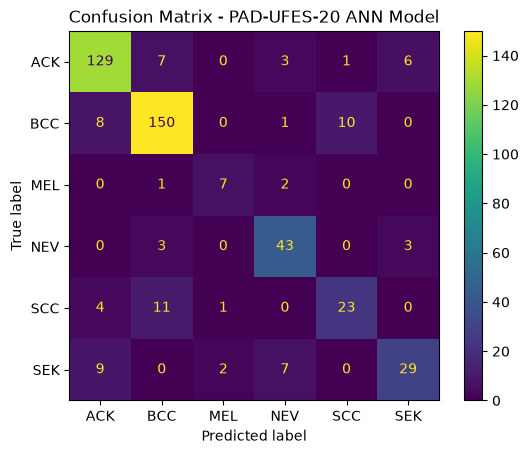

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display confusion matrix
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

plt.figure(figsize=(8, 6))
display.plot()
plt.title("Confusion Matrix - PAD-UFES-20 ANN Model")
plt.show()

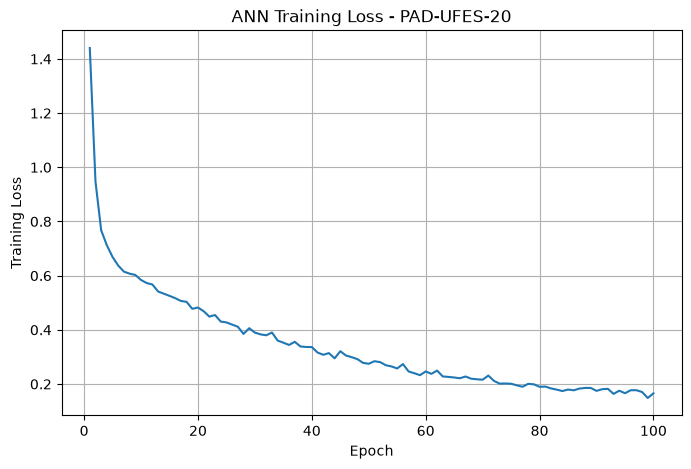

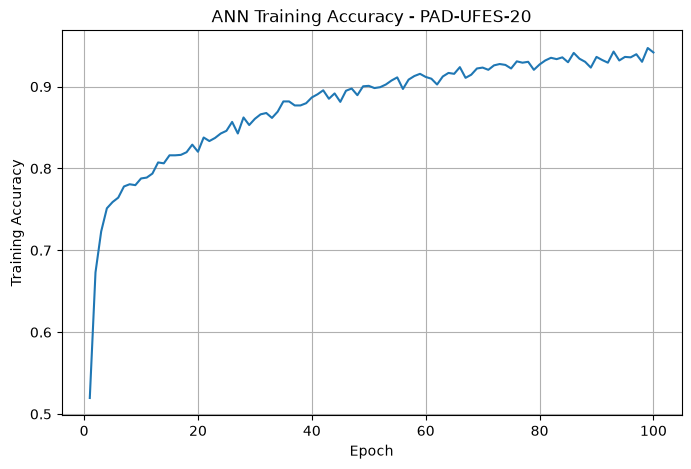

In [25]:
import matplotlib.pyplot as plt

# Create epoch numbers
epoch_numbers = range(1, epochs + 1)

# Training Loss Graph
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("ANN Training Loss - PAD-UFES-20")
plt.grid(True)
plt.show()

# Training Accuracy Graph
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("ANN Training Accuracy - PAD-UFES-20")
plt.grid(True)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

# Split the training data into training and validation sets
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.20,
    random_state=42,
    stratify=y_train_final
)

print("New training samples:", X_train_new.shape[0])
print("Validation samples:", X_val.shape[0])
print("Final untouched test samples:", X_test_final.shape[0])

New training samples: 1470
Validation samples: 368
Final untouched test samples: 460


In [27]:
from sklearn.model_selection import train_test_split

# Split current training data into training and validation data
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.20,
    random_state=42,
    stratify=y_train_final
)

print("New training samples:", X_train_new.shape[0])
print("Validation samples:", X_val.shape[0])
print("Final untouched test samples:", X_test_final.shape[0])

New training samples: 1470
Validation samples: 368
Final untouched test samples: 460


In [28]:
# Convert training and validation data to PyTorch tensors

X_train_new_tensor = torch.tensor(
    X_train_new,
    dtype=torch.float32
)

y_train_new_tensor = torch.tensor(
    y_train_new,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

print("New training tensor:", X_train_new_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)
print("Final test tensor:", X_test_tensor.shape)

New training tensor: torch.Size([1470, 78])
Validation tensor: torch.Size([368, 78])
Final test tensor: torch.Size([460, 78])


In [29]:
from torch.utils.data import TensorDataset, DataLoader

# datasets
train_new_dataset = TensorDataset(
    X_train_new_tensor,
    y_train_new_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)


batch_size = 32


train_new_loader = DataLoader(
    train_new_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training batches:", len(train_new_loader))
print("Validation batches:", len(val_loader))

Training batches: 46
Validation batches: 12


In [30]:
# Reset the random seed
torch.manual_seed(SEED)

# Create a fresh ANN model
model_improved = SkinDiseaseANN(
    input_size=input_size,
    num_classes=num_classes
)

# Loss function
criterion_improved = nn.CrossEntropyLoss()

# Optimizer
optimizer_improved = torch.optim.Adam(
    model_improved.parameters(),
    lr=0.001
)

print(model_improved)
print("\nImproved model created successfully!")

SkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=6, bias=True)
  )
)

Improved model created successfully!


In [31]:
# Number of training epochs
epochs = 100

# Lists to store training and validation history
train_losses_improved = []
train_accuracies_improved = []

val_losses = []
val_accuracies = []

# Variables to track the best model
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(epochs):

    # =========================
    # TRAINING
    # =========================
    model_improved.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_new_loader:

        # Reset gradients
        optimizer_improved.zero_grad()

        # Forward propagation
        outputs = model_improved(inputs)

        # Calculate loss
        loss = criterion_improved(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights and biases
        optimizer_improved.step()

        # Store training loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Calculate training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    train_losses_improved.append(train_loss)
    train_accuracies_improved.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    model_improved.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            # Forward pass
            outputs = model_improved(inputs)

            # Calculate validation loss
            loss = criterion_improved(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            # Calculate validation accuracy
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Calculate validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        # Save the best model weights
        torch.save(
            model_improved.state_dict(),
            "../models/PAD_UFES_20_best_model.pth"
        )


    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nTraining completed!")
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))

Epoch [1/100] | Train Loss: 1.5011 | Train Acc: 0.4878 | Val Loss: 1.2332 | Val Acc: 0.5815
Epoch [10/100] | Train Loss: 0.5834 | Train Acc: 0.7891 | Val Loss: 0.6514 | Val Acc: 0.7663
Epoch [20/100] | Train Loss: 0.4633 | Train Acc: 0.8361 | Val Loss: 0.6523 | Val Acc: 0.7609
Epoch [30/100] | Train Loss: 0.3817 | Train Acc: 0.8585 | Val Loss: 0.6815 | Val Acc: 0.7663
Epoch [40/100] | Train Loss: 0.3186 | Train Acc: 0.8925 | Val Loss: 0.7424 | Val Acc: 0.7880
Epoch [50/100] | Train Loss: 0.2916 | Train Acc: 0.8952 | Val Loss: 0.7980 | Val Acc: 0.7717
Epoch [60/100] | Train Loss: 0.2545 | Train Acc: 0.9095 | Val Loss: 0.8469 | Val Acc: 0.7880
Epoch [70/100] | Train Loss: 0.2064 | Train Acc: 0.9320 | Val Loss: 0.9466 | Val Acc: 0.7826
Epoch [80/100] | Train Loss: 0.1920 | Train Acc: 0.9293 | Val Loss: 1.0139 | Val Acc: 0.7989
Epoch [90/100] | Train Loss: 0.1642 | Train Acc: 0.9361 | Val Loss: 1.0892 | Val Acc: 0.7853
Epoch [100/100] | Train Loss: 0.1615 | Train Acc: 0.9422 | Val Loss: 1.

In [32]:
# Create a fresh model with the same architecture
best_model = SkinDiseaseANN(
    input_size=input_size,
    num_classes=num_classes
)

# Load the weights from the best validation epoch
best_model.load_state_dict(
    torch.load(
        "../models/PAD_UFES_20_best_model.pth",
        map_location=torch.device("cpu")
    )
)

# Set the model to evaluation mode
best_model.eval()

print("Best model loaded successfully!")
print("Best epoch:", best_epoch)

Best model loaded successfully!
Best epoch: 18


In [33]:
# Evaluate the best model on the untouched test dataset

test_correct = 0
test_total = 0
best_test_loss = 0.0

best_predictions = []
best_true_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_model(inputs)

        # Calculate loss
        loss = criterion_improved(outputs, labels)

        best_test_loss += loss.item() * inputs.size(0)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and actual labels
        best_predictions.extend(predicted.numpy())
        best_true_labels.extend(labels.numpy())

        # Calculate accuracy
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()


# Final metrics
best_test_loss = best_test_loss / test_total
best_test_accuracy = test_correct / test_total

print("Best Model Test Loss:", round(best_test_loss, 4))
print("Best Model Test Accuracy:", round(best_test_accuracy * 100, 2), "%")

Best Model Test Loss: 0.5705
Best Model Test Accuracy: 78.04 %


In [35]:
from sklearn.utils.class_weight import compute_class_weight

# Get class labels
classes = np.unique(y_train_new)

# Calculate balanced class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_new
)

# Convert to PyTorch tensor
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:")

for class_name, weight in zip(label_encoder.classes_, class_weights):
    print(f"{class_name}: {weight:.4f}")

Class weights:
ACK: 0.5246
BCC: 0.4529
MEL: 7.2059
NEV: 1.5705
SCC: 2.0082
SEK: 1.6333


In [36]:
# Reset random seed
torch.manual_seed(SEED)

# Create a fresh ANN model
model_weighted = SkinDiseaseANN(
    input_size=input_size,
    num_classes=num_classes
)

# Weighted loss function
criterion_weighted = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

# Adam optimizer
optimizer_weighted = torch.optim.Adam(
    model_weighted.parameters(),
    lr=0.001
)

print("Class-Weighted ANN created successfully!")
print(model_weighted)

Class-Weighted ANN created successfully!
SkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [37]:
# Number of training epochs
epochs_weighted = 100

# Store training history
weighted_train_losses = []
weighted_train_accuracies = []

weighted_val_losses = []
weighted_val_accuracies = []

# Track the best model
best_weighted_val_loss = float("inf")
best_weighted_epoch = 0


for epoch in range(epochs_weighted):

    # =========================
    # TRAINING
    # =========================
    model_weighted.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_new_loader:

        # Reset gradients
        optimizer_weighted.zero_grad()

        # Forward pass
        outputs = model_weighted(inputs)

        # Calculate weighted loss
        loss = criterion_weighted(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer_weighted.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate predictions
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()


    # Calculate training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    weighted_train_losses.append(train_loss)
    weighted_train_accuracies.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    model_weighted.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            # Forward pass
            outputs = model_weighted(inputs)

            # Calculate validation loss
            loss = criterion_weighted(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            # Get predictions
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()


    # Calculate validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    weighted_val_losses.append(val_loss)
    weighted_val_accuracies.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_weighted_val_loss:

        best_weighted_val_loss = val_loss
        best_weighted_epoch = epoch + 1

        torch.save(
            model_weighted.state_dict(),
            "../models/PAD_UFES_20_weighted_best_model.pth"
        )


    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs_weighted}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nWeighted training completed!")
print("Best epoch:", best_weighted_epoch)
print("Best validation loss:", round(best_weighted_val_loss, 4))

Epoch [1/100] | Train Loss: 1.7020 | Train Acc: 0.3401 | Val Loss: 1.5267 | Val Acc: 0.6766
Epoch [10/100] | Train Loss: 0.6406 | Train Acc: 0.7177 | Val Loss: 0.7646 | Val Acc: 0.6821
Epoch [20/100] | Train Loss: 0.4989 | Train Acc: 0.7639 | Val Loss: 0.8294 | Val Acc: 0.7065
Epoch [30/100] | Train Loss: 0.4184 | Train Acc: 0.8048 | Val Loss: 0.9139 | Val Acc: 0.7038
Epoch [40/100] | Train Loss: 0.3676 | Train Acc: 0.8320 | Val Loss: 0.9631 | Val Acc: 0.7500
Epoch [50/100] | Train Loss: 0.3154 | Train Acc: 0.8531 | Val Loss: 1.0593 | Val Acc: 0.7473
Epoch [60/100] | Train Loss: 0.2929 | Train Acc: 0.8605 | Val Loss: 1.1386 | Val Acc: 0.7690
Epoch [70/100] | Train Loss: 0.2529 | Train Acc: 0.8898 | Val Loss: 1.2397 | Val Acc: 0.7554
Epoch [80/100] | Train Loss: 0.2185 | Train Acc: 0.9034 | Val Loss: 1.4451 | Val Acc: 0.7663
Epoch [90/100] | Train Loss: 0.1873 | Train Acc: 0.9054 | Val Loss: 1.5894 | Val Acc: 0.7799
Epoch [100/100] | Train Loss: 0.1910 | Train Acc: 0.9136 | Val Loss: 1.

In [38]:
# Create a fresh model
best_weighted_model = SkinDiseaseANN(
    input_size=input_size,
    num_classes=num_classes
)

# Load the best saved weighted model
best_weighted_model.load_state_dict(
    torch.load(
        "../models/PAD_UFES_20_weighted_best_model.pth",
        map_location=torch.device("cpu")
    )
)

# Evaluation mode
best_weighted_model.eval()

print("Best weighted model loaded successfully!")
print("Best epoch:", best_weighted_epoch)

Best weighted model loaded successfully!
Best epoch: 10


In [39]:
# Evaluate the best weighted model on the untouched test set

weighted_test_correct = 0
weighted_test_total = 0
weighted_test_loss = 0.0

weighted_predictions = []
weighted_true_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_weighted_model(inputs)

        # Calculate loss
        loss = criterion_weighted(outputs, labels)

        weighted_test_loss += loss.item() * inputs.size(0)

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Store predictions and true labels
        weighted_predictions.extend(predicted.numpy())
        weighted_true_labels.extend(labels.numpy())

        # Accuracy
        weighted_test_total += labels.size(0)
        weighted_test_correct += (
            predicted == labels
        ).sum().item()


# Final results
weighted_test_loss = (
    weighted_test_loss / weighted_test_total
)

weighted_test_accuracy = (
    weighted_test_correct / weighted_test_total
)

print("Weighted Model Test Loss:",
      round(weighted_test_loss, 4))

print("Weighted Model Test Accuracy:",
      round(weighted_test_accuracy * 100, 2), "%")

Weighted Model Test Loss: 0.6922
Weighted Model Test Accuracy: 71.09 %


In [41]:
#SMALLER ANN

import torch
import torch.nn as nn
import torch.optim as optim


class SmallSkinDiseaseANN(nn.Module):

    def __init__(self, input_size, num_classes):
        super(SmallSkinDiseaseANN, self).__init__()

        self.network = nn.Sequential(

            # First hidden layer
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Second hidden layer
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output layer
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Create Model 2
small_model = SmallSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

# Loss function
small_criterion = nn.CrossEntropyLoss()

# Adam optimizer
small_optimizer = optim.Adam(
    small_model.parameters(),
    lr=0.001
)

print(small_model)

SmallSkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=6, bias=True)
  )
)


In [42]:
# Number of epochs
small_epochs = 50

# Store training history
small_train_losses = []
small_train_accuracies = []

small_val_losses = []
small_val_accuracies = []

# Track best model
best_small_val_loss = float("inf")
best_small_epoch = 0


for epoch in range(small_epochs):

    # =========================
    # TRAINING
    # =========================
    small_model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in train_loader:

        # Reset gradients
        small_optimizer.zero_grad()

        # Forward pass
        outputs = small_model(inputs)

        # Calculate loss
        loss = small_criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        small_optimizer.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Training metrics
    train_loss = running_train_loss / train_total
    train_accuracy = train_correct / train_total

    small_train_losses.append(train_loss)
    small_train_accuracies.append(train_accuracy)


    # =========================
    # VALIDATION
    # =========================
    small_model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = small_model(inputs)

            loss = small_criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Validation metrics
    val_loss = running_val_loss / val_total
    val_accuracy = val_correct / val_total

    small_val_losses.append(val_loss)
    small_val_accuracies.append(val_accuracy)


    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_loss < best_small_val_loss:

        best_small_val_loss = val_loss
        best_small_epoch = epoch + 1

        torch.save(
            small_model.state_dict(),
            "../models/PAD_UFES_20_small_best_model.pth"
        )


    # Print progress
    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{small_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nSmall ANN training completed!")
print("Best epoch:", best_small_epoch)
print("Best validation loss:", round(best_small_val_loss, 4))

Epoch [1/50] | Train Loss: 1.5324 | Train Acc: 0.4837 | Val Loss: 1.2204 | Val Acc: 0.5870
Epoch [5/50] | Train Loss: 0.7678 | Train Acc: 0.7307 | Val Loss: 0.6976 | Val Acc: 0.7609
Epoch [10/50] | Train Loss: 0.6530 | Train Acc: 0.7579 | Val Loss: 0.5832 | Val Acc: 0.7853
Epoch [15/50] | Train Loss: 0.5993 | Train Acc: 0.7748 | Val Loss: 0.5503 | Val Acc: 0.8043
Epoch [20/50] | Train Loss: 0.5594 | Train Acc: 0.8009 | Val Loss: 0.4985 | Val Acc: 0.8125
Epoch [25/50] | Train Loss: 0.5490 | Train Acc: 0.8025 | Val Loss: 0.4737 | Val Acc: 0.8261
Epoch [30/50] | Train Loss: 0.5155 | Train Acc: 0.8156 | Val Loss: 0.4499 | Val Acc: 0.8397
Epoch [35/50] | Train Loss: 0.4771 | Train Acc: 0.8330 | Val Loss: 0.4156 | Val Acc: 0.8614
Epoch [40/50] | Train Loss: 0.4664 | Train Acc: 0.8324 | Val Loss: 0.4010 | Val Acc: 0.8533
Epoch [45/50] | Train Loss: 0.4576 | Train Acc: 0.8292 | Val Loss: 0.3693 | Val Acc: 0.8614
Epoch [50/50] | Train Loss: 0.4163 | Train Acc: 0.8493 | Val Loss: 0.3509 | Val Ac

In [43]:
# Create a fresh Small ANN model

best_small_model = SmallSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

# Load the best saved weights

best_small_model.load_state_dict(
    torch.load(
        "../models/PAD_UFES_20_small_best_model.pth"
    )
)

# Evaluation mode

best_small_model.eval()


# Variables for evaluation

small_test_loss = 0.0
small_test_correct = 0
small_test_total = 0

small_all_predictions = []
small_all_labels = []


# Evaluate on test data

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_small_model(inputs)

        # Calculate loss
        loss = small_criterion(outputs, labels)

        small_test_loss += (
            loss.item() * inputs.size(0)
        )

        # Predicted class
        _, predicted = torch.max(outputs, 1)

        # Accuracy calculation
        small_test_total += labels.size(0)

        small_test_correct += (
            predicted == labels
        ).sum().item()

        # Store predictions and actual labels
        small_all_predictions.extend(
            predicted.cpu().numpy()
        )

        small_all_labels.extend(
            labels.cpu().numpy()
        )


# Final test metrics

small_test_loss = (
    small_test_loss / small_test_total
)

small_test_accuracy = (
    small_test_correct / small_test_total
)


print(
    f"Small ANN Test Loss: "
    f"{small_test_loss:.4f}"
)

print(
    f"Small ANN Test Accuracy: "
    f"{small_test_accuracy * 100:.2f} %"
)

Small ANN Test Loss: 0.5251
Small ANN Test Accuracy: 81.30 %


In [50]:
###########################################################

In [44]:
#DEEPANN

class DeepSkinDiseaseANN(nn.Module):

    def __init__(self, input_size, num_classes):
        super(DeepSkinDiseaseANN, self).__init__()

        self.network = nn.Sequential(

            # Hidden Layer 1
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 2
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Hidden Layer 3
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output Layer
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Create Model 3

deep_model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)

# Loss function

deep_criterion = nn.CrossEntropyLoss()

# Adam optimizer

deep_optimizer = optim.Adam(
    deep_model.parameters(),
    lr=0.001
)

print(deep_model)

DeepSkinDiseaseANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [45]:
# Number of epochs
deep_epochs = 50


# Store training history

deep_train_losses = []
deep_train_accuracies = []

deep_val_losses = []
deep_val_accuracies = []


# Track the best model

best_deep_val_loss = float("inf")
best_deep_epoch = 0


# =========================
# TRAINING LOOP
# =========================

for epoch in range(deep_epochs):

    # ----- Training -----

    deep_model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0


    for inputs, labels in train_loader:

        # Reset gradients
        deep_optimizer.zero_grad()

        # Forward pass
        outputs = deep_model(inputs)

        # Calculate loss
        loss = deep_criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        deep_optimizer.step()

        # Store loss
        running_train_loss += loss.item() * inputs.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (
            predicted == labels
        ).sum().item()


    # Calculate training metrics

    train_loss = (
        running_train_loss / train_total
    )

    train_accuracy = (
        train_correct / train_total
    )

    deep_train_losses.append(train_loss)
    deep_train_accuracies.append(train_accuracy)


    # ----- Validation -----

    deep_model.eval()

    running_val_loss = 0.0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for inputs, labels in val_loader:

            # Forward pass
            outputs = deep_model(inputs)

            # Calculate validation loss
            loss = deep_criterion(outputs, labels)

            running_val_loss += (
                loss.item() * inputs.size(0)
            )

            # Predictions
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    # Calculate validation metrics

    val_loss = (
        running_val_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )

    deep_val_losses.append(val_loss)
    deep_val_accuracies.append(val_accuracy)


    # ----- Save best model -----

    if val_loss < best_deep_val_loss:

        best_deep_val_loss = val_loss
        best_deep_epoch = epoch + 1

        torch.save(
            deep_model.state_dict(),
            "../models/PAD_UFES_20_deep_best_model.pth"
        )


    # Print progress

    if (epoch + 1) % 5 == 0 or epoch == 0:

        print(
            f"Epoch [{epoch + 1}/{deep_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


print("\nDeep ANN training completed!")

print("Best epoch:", best_deep_epoch)

print(
    "Best validation loss:",
    round(best_deep_val_loss, 4)
)

Epoch [1/50] | Train Loss: 1.2906 | Train Acc: 0.5403 | Val Loss: 0.9667 | Val Acc: 0.6332
Epoch [5/50] | Train Loss: 0.6557 | Train Acc: 0.7612 | Val Loss: 0.5952 | Val Acc: 0.7935
Epoch [10/50] | Train Loss: 0.5552 | Train Acc: 0.7992 | Val Loss: 0.4813 | Val Acc: 0.8261
Epoch [15/50] | Train Loss: 0.4744 | Train Acc: 0.8330 | Val Loss: 0.3786 | Val Acc: 0.8696
Epoch [20/50] | Train Loss: 0.3820 | Train Acc: 0.8662 | Val Loss: 0.3005 | Val Acc: 0.8777
Epoch [25/50] | Train Loss: 0.3195 | Train Acc: 0.8765 | Val Loss: 0.2303 | Val Acc: 0.9212
Epoch [30/50] | Train Loss: 0.2733 | Train Acc: 0.9037 | Val Loss: 0.1721 | Val Acc: 0.9293
Epoch [35/50] | Train Loss: 0.2307 | Train Acc: 0.9113 | Val Loss: 0.1421 | Val Acc: 0.9457
Epoch [40/50] | Train Loss: 0.2171 | Train Acc: 0.9211 | Val Loss: 0.1099 | Val Acc: 0.9620
Epoch [45/50] | Train Loss: 0.1798 | Train Acc: 0.9347 | Val Loss: 0.0959 | Val Acc: 0.9701
Epoch [50/50] | Train Loss: 0.1678 | Train Acc: 0.9358 | Val Loss: 0.0870 | Val Ac

In [46]:
# Create a fresh Deep ANN model

best_deep_model = DeepSkinDiseaseANN(
    input_size=78,
    num_classes=6
)


# Load the best saved model

best_deep_model.load_state_dict(
    torch.load(
        "../models/PAD_UFES_20_deep_best_model.pth"
    )
)

best_deep_model.eval()


# Variables for evaluation

deep_test_loss = 0.0
deep_test_correct = 0
deep_test_total = 0

deep_all_predictions = []
deep_all_labels = []


# Evaluate on test data

with torch.no_grad():

    for inputs, labels in test_loader:

        # Forward pass
        outputs = best_deep_model(inputs)

        # Calculate loss
        loss = deep_criterion(outputs, labels)

        deep_test_loss += (
            loss.item() * inputs.size(0)
        )

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Calculate accuracy
        deep_test_total += labels.size(0)

        deep_test_correct += (
            predicted == labels
        ).sum().item()

        # Store predictions and labels
        deep_all_predictions.extend(
            predicted.cpu().numpy()
        )

        deep_all_labels.extend(
            labels.cpu().numpy()
        )


# Final test metrics

deep_test_loss = (
    deep_test_loss / deep_test_total
)

deep_test_accuracy = (
    deep_test_correct / deep_test_total
)


print(
    f"Deep ANN Test Loss: "
    f"{deep_test_loss:.4f}"
)

print(
    f"Deep ANN Test Accuracy: "
    f"{deep_test_accuracy * 100:.2f} %"
)

Deep ANN Test Loss: 0.7319
Deep ANN Test Accuracy: 83.48 %


In [47]:
# Save the final selected Deep ANN model

torch.save(
    best_deep_model.state_dict(),
    "../models/PAD_UFES_20_FINAL_ANN.pth"
)

print("Final ANN model saved successfully!")

Final ANN model saved successfully!


In [48]:
from sklearn.metrics import classification_report

# Class names in the same order as the label encoding
class_names = [
    "ACK",
    "BCC",
    "MEL",
    "NEV",
    "SCC",
    "SEK"
]

# Generate classification report
deep_classification_report = classification_report(
    deep_all_labels,
    deep_all_predictions,
    target_names=class_names,
    digits=4
)

print(
    "Classification Report - Final Deep ANN Model\n"
)

print(deep_classification_report)

Classification Report - Final Deep ANN Model

              precision    recall  f1-score   support

         ACK     0.8609    0.8904    0.8754       146
         BCC     0.8882    0.8935    0.8909       169
         MEL     0.6667    0.6000    0.6316        10
         NEV     0.7458    0.8980    0.8148        49
         SCC     0.7143    0.6410    0.6757        39
         SEK     0.7778    0.5957    0.6747        47

    accuracy                         0.8348       460
   macro avg     0.7756    0.7531    0.7605       460
weighted avg     0.8335    0.8348    0.8319       460



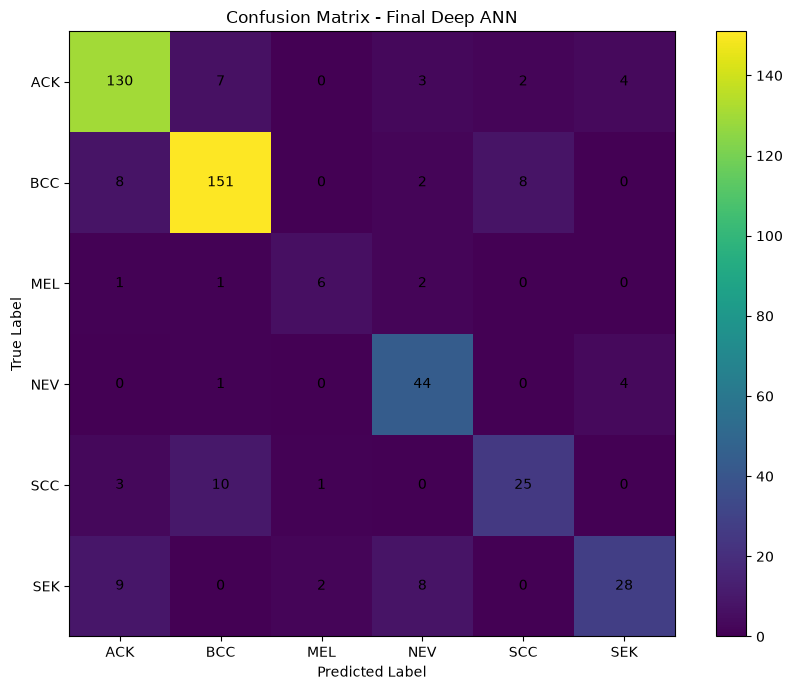

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm_deep = confusion_matrix(
    deep_all_labels,
    deep_all_predictions
)

# Create figure
plt.figure(figsize=(9, 7))

plt.imshow(cm_deep)

# Add title and labels
plt.title("Confusion Matrix - Final Deep ANN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add class labels
plt.xticks(
    np.arange(len(class_names)),
    class_names
)

plt.yticks(
    np.arange(len(class_names)),
    class_names
)

# Add values inside each cell
for i in range(cm_deep.shape[0]):
    for j in range(cm_deep.shape[1]):

        plt.text(
            j,
            i,
            str(cm_deep[i, j]),
            ha="center",
            va="center"
        )

# Add color bar
plt.colorbar()

# Improve layout
plt.tight_layout()

# Show plot
plt.show()

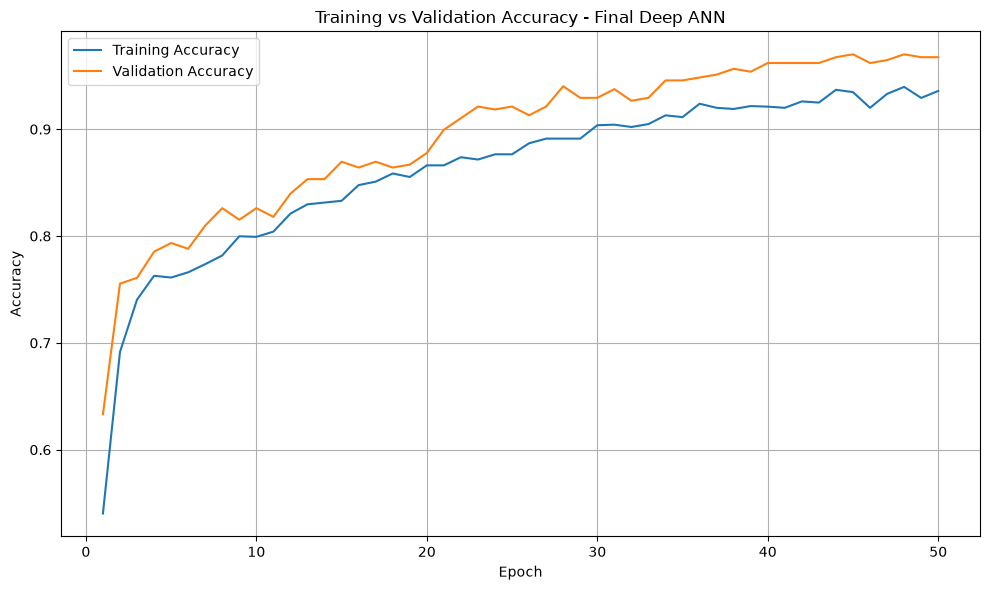

In [51]:
import matplotlib.pyplot as plt

# Create epoch numbers
epochs = range(1, len(deep_train_accuracies) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    deep_train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    deep_val_accuracies,
    label="Validation Accuracy"
)

# Add labels and title
plt.title("Training vs Validation Accuracy - Final Deep ANN")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

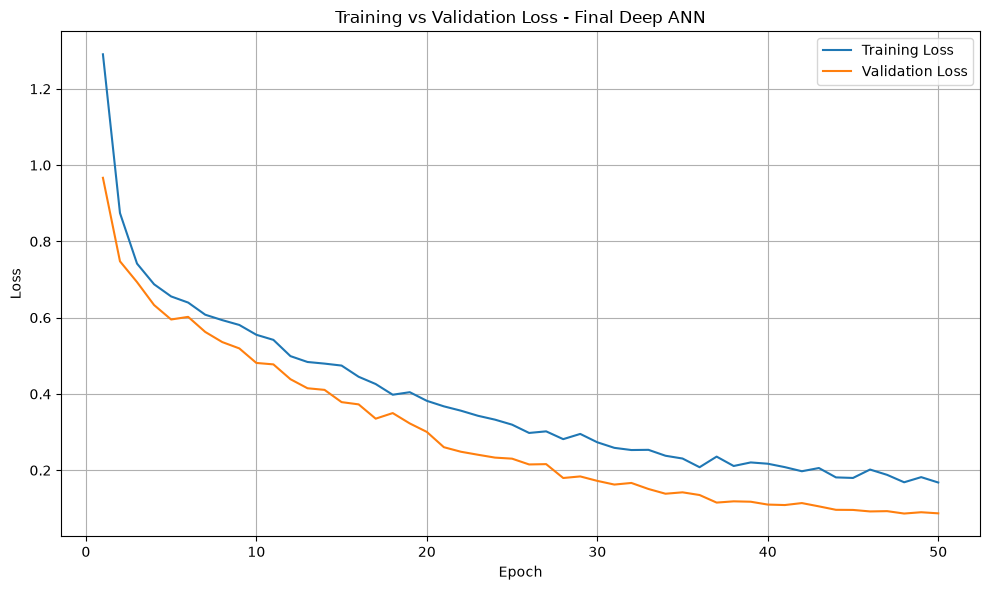

In [52]:
# Create epoch numbers
epochs = range(1, len(deep_train_losses) + 1)

# Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    deep_train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    deep_val_losses,
    label="Validation Loss"
)

# Add labels and title
plt.title("Training vs Validation Loss - Final Deep ANN")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Improve layout
plt.tight_layout()

# Show graph
plt.show()

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

model_comparison = pd.DataFrame({

    "Model": [
        "Model 1 - Original ANN",
        "Model 2 - Small ANN",
        "Model 3 - Deep ANN"
    ],

    "Architecture": [
        "78 → 128 → 64 → 6",
        "78 → 64 → 32 → 6",
        "78 → 256 → 128 → 64 → 6"
    ],

    "Test Loss": [
        0.7330,
        0.5251,
        0.7319
    ],

    "Test Accuracy (%)": [
        82.83,
        81.30,
        83.48
    ]

})

print(model_comparison)

                    Model             Architecture  Test Loss  \
0  Model 1 - Original ANN        78 → 128 → 64 → 6     0.7330   
1     Model 2 - Small ANN         78 → 64 → 32 → 6     0.5251   
2      Model 3 - Deep ANN  78 → 256 → 128 → 64 → 6     0.7319   

   Test Accuracy (%)  
0              82.83  
1              81.30  
2              83.48  


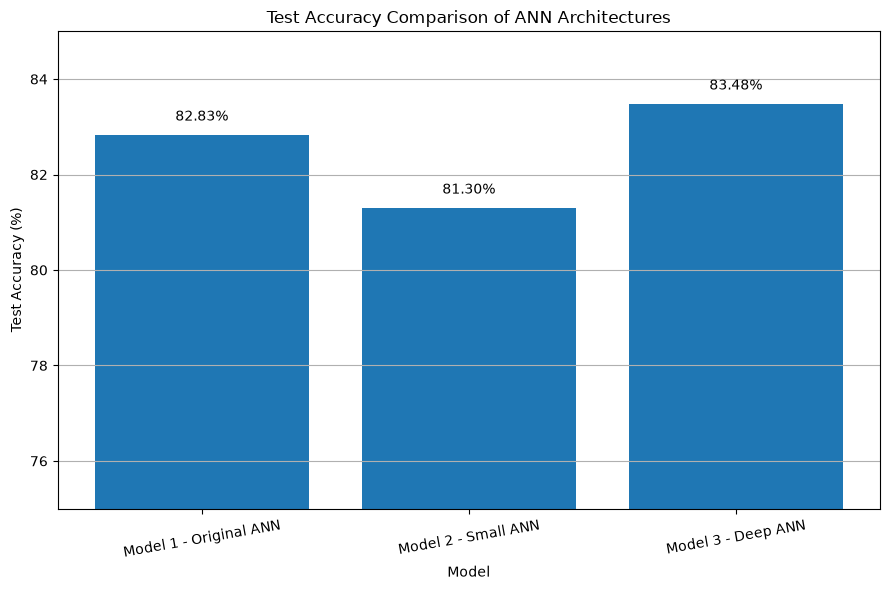

In [55]:
# Create model comparison accuracy graph

plt.figure(figsize=(9, 6))

plt.bar(
    model_comparison["Model"],
    model_comparison["Test Accuracy (%)"]
)

# Add title and labels
plt.title("Test Accuracy Comparison of ANN Architectures")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")

# Add accuracy values above bars
for index, value in enumerate(
    model_comparison["Test Accuracy (%)"]
):

    plt.text(
        index,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

# Set graph range for better comparison
plt.ylim(75, 85)

plt.xticks(rotation=10)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

In [3]:
import os
import pandas as pd

dataset_path = r"D:\DermaVision_Module1\dataset"

pad_path = os.path.join(
    dataset_path,
    "PAD_UFES_20"
)

print("PAD-UFES-20 folder:")
print(os.listdir(pad_path))

PAD-UFES-20 folder:
['metadata.csv']


In [4]:
pad_df = pd.read_csv(
    os.path.join(pad_path, "metadata.csv")
)

print("Dataset shape:", pad_df.shape)

print("\nFirst 5 rows:")
display(pad_df.head())

Dataset shape: (2298, 26)

First 5 rows:


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [5]:
important_columns = [
    "smoke",
    "drink",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "fitspatrick",
    "itch",
    "grew",
    "hurt",
    "changed",
    "bleed",
    "elevation",
    "diagnostic"
]

for column in important_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(pad_df[column].value_counts(dropna=False))


smoke
smoke
False    1292
NaN       804
True      202
Name: count, dtype: int64

drink
drink
False    1126
NaN       804
True      368
Name: count, dtype: int64

pesticide
pesticide
False    897
NaN      804
True     597
Name: count, dtype: int64

gender
gender
NaN       804
FEMALE    753
MALE      741
Name: count, dtype: int64

skin_cancer_history
skin_cancer_history
False    813
NaN      804
True     681
Name: count, dtype: int64

cancer_history
cancer_history
NaN      804
True     779
False    715
Name: count, dtype: int64

fitspatrick
fitspatrick
2.0    876
NaN    804
3.0    392
1.0    153
4.0     62
5.0     10
6.0      1
Name: count, dtype: int64

itch
itch
True     1455
False     837
UNK         6
Name: count, dtype: int64

grew
grew
False    971
True     925
UNK      402
Name: count, dtype: int64

hurt
hurt
False    1891
True      397
UNK        10
Name: count, dtype: int64

changed
changed
False    1700
UNK       396
True      202
Name: count, dtype: int64

bleed
bleed
False  

In [6]:
missing_check_columns = [
    "smoke",
    "drink",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "fitspatrick"
]

missing_pattern = (
    pad_df[missing_check_columns]
    .isnull()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

print("Number of missing values per row:")
print(missing_pattern)

Number of missing values per row:
0    1494
7     804
Name: count, dtype: int64


In [7]:
print("Age missing:", pad_df["age"].isna().sum())

print("Diagnostic missing:", pad_df["diagnostic"].isna().sum())

print("\nAge distribution summary:")
print(pad_df["age"].describe())

print("\nUnique patients:")
print(pad_df["patient_id"].nunique())

print("Unique lesions:")
print(
    pad_df[["patient_id", "lesion_id"]]
    .drop_duplicates()
    .shape[0]
)

Age missing: 0
Diagnostic missing: 0

Age distribution summary:
count    2298.000000
mean       60.464752
std        15.894866
min         6.000000
25%        52.000000
50%        62.000000
75%        72.000000
max        94.000000
Name: age, dtype: float64

Unique patients:
1373
Unique lesions:
1891


In [8]:
pad_lesion_df = (
    pad_df
    .drop_duplicates(
        subset=["patient_id", "lesion_id"],
        keep="first"
    )
    .reset_index(drop=True)
)

print("Lesion-level dataset shape:", pad_lesion_df.shape)

print("Unique patients:", pad_lesion_df["patient_id"].nunique())

print(
    "Unique lesions:",
    pad_lesion_df[["patient_id", "lesion_id"]]
    .drop_duplicates()
    .shape[0]
)

Lesion-level dataset shape: (1891, 26)
Unique patients: 1373
Unique lesions: 1891


In [9]:
diagnosis_check = (
    pad_df
    .groupby(["patient_id", "lesion_id"])["diagnostic"]
    .nunique()
)

conflicting_diagnoses = diagnosis_check[
    diagnosis_check > 1
]

print(
    "Lesions with more than one diagnosis:",
    len(conflicting_diagnoses)
)

if len(conflicting_diagnoses) > 0:
    print("\nConflicting lesions:")
    print(conflicting_diagnoses.head(20))

Lesions with more than one diagnosis: 0


In [10]:
diagnosis_mapping = {
    "BCC": "basal cell carcinoma",
    "ACK": "actinic keratosis",
    "NEV": "nevus",
    "SEK": "seborrheic keratosis",
    "SCC": "squamous cell carcinoma",
    "MEL": "melanoma"
}

pad_lesion_df["Diagnosis"] = (
    pad_lesion_df["diagnostic"]
    .map(diagnosis_mapping)
)

print("Standardized diagnosis distribution:\n")

print(
    pad_lesion_df["Diagnosis"]
    .value_counts()
)

print("\nMissing diagnoses:")
print(pad_lesion_df["Diagnosis"].isna().sum())

Standardized diagnosis distribution:

Diagnosis
basal cell carcinoma       652
actinic keratosis          644
nevus                      216
seborrheic keratosis       198
squamous cell carcinoma    145
melanoma                    36
Name: count, dtype: int64

Missing diagnoses:
0


In [11]:
pad_missing_columns = [
    "smoke",
    "drink",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "fitspatrick"
]

print("Missing values at lesion level:\n")

print(
    pad_lesion_df[pad_missing_columns]
    .isnull()
    .sum()
)

print("\nMissing values per lesion:")
print(
    pad_lesion_df[pad_missing_columns]
    .isnull()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

Missing values at lesion level:

smoke                  712
drink                  712
pesticide              712
gender                 712
skin_cancer_history    712
cancer_history         712
fitspatrick            712
dtype: int64

Missing values per lesion:
0    1179
7     712
Name: count, dtype: int64


In [12]:
pad_fill_columns = [
    "smoke",
    "drink",
    "pesticide",
    "gender",
    "skin_cancer_history",
    "cancer_history",
    "fitspatrick"
]

for column in pad_fill_columns:
    pad_lesion_df[column] = (
        pad_lesion_df[column]
        .astype("object")
        .fillna("Unknown")
    )

print("Remaining missing values:\n")

print(
    pad_lesion_df[pad_fill_columns]
    .isnull()
    .sum()
)

Remaining missing values:

smoke                  0
drink                  0
pesticide              0
gender                 0
skin_cancer_history    0
cancer_history         0
fitspatrick            0
dtype: int64


In [13]:
pad_final = pd.DataFrame({

    "Participant_ID": pad_lesion_df["patient_id"].astype(str),

    "Lesion_ID": pad_lesion_df["lesion_id"].astype(str),

    "Age": pad_lesion_df["age"],

    "Sex": pad_lesion_df["gender"].replace({
        "MALE": "Male",
        "FEMALE": "Female"
    }),

    "Skin_Type": pad_lesion_df["fitspatrick"],

    "Smoking": pad_lesion_df["smoke"],

    "Alcohol_Consumption": pad_lesion_df["drink"],

    "Pesticide_Exposure": pad_lesion_df["pesticide"],

    "Skin_Cancer_History": pad_lesion_df["skin_cancer_history"],

    "Cancer_History": pad_lesion_df["cancer_history"],

    "Itch": pad_lesion_df["itch"],

    "Grew": pad_lesion_df["grew"],

    "Hurt": pad_lesion_df["hurt"],

    "Changed": pad_lesion_df["changed"],

    "Bleed": pad_lesion_df["bleed"],

    "Elevation": pad_lesion_df["elevation"],

    "Diagnosis": pad_lesion_df["Diagnosis"],

    "Source_Dataset": "PAD-UFES-20"
})

print("Final PAD-UFES-20 shape:", pad_final.shape)

print("\nColumns:")
print(pad_final.columns.tolist())

print("\nMissing values:")
print(pad_final.isnull().sum())

Final PAD-UFES-20 shape: (1891, 18)

Columns:
['Participant_ID', 'Lesion_ID', 'Age', 'Sex', 'Skin_Type', 'Smoking', 'Alcohol_Consumption', 'Pesticide_Exposure', 'Skin_Cancer_History', 'Cancer_History', 'Itch', 'Grew', 'Hurt', 'Changed', 'Bleed', 'Elevation', 'Diagnosis', 'Source_Dataset']

Missing values:
Participant_ID         0
Lesion_ID              0
Age                    0
Sex                    0
Skin_Type              0
Smoking                0
Alcohol_Consumption    0
Pesticide_Exposure     0
Skin_Cancer_History    0
Cancer_History         0
Itch                   0
Grew                   0
Hurt                   0
Changed                0
Bleed                  0
Elevation              0
Diagnosis              0
Source_Dataset         0
dtype: int64


In [14]:
pad_output_path = os.path.join(
    dataset_path,
    "PAD_UFES_20",
    "PAD_UFES_20_Final_Structured.csv"
)

pad_final.to_csv(
    pad_output_path,
    index=False
)

print("Dataset saved successfully!")
print("\nLocation:")
print(pad_output_path)

print("\nFinal shape:", pad_final.shape)

Dataset saved successfully!

Location:
D:\DermaVision_Module1\dataset\PAD_UFES_20\PAD_UFES_20_Final_Structured.csv

Final shape: (1891, 18)


In [1]:
###DEEP_ANN_MODEL_TESTING######################

In [4]:
model_path = r"D:\DermaVision_Module1\models\PAD_UFES_20_deep_best_model.pth"

In [5]:
model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Best PAD-UFES Deep ANN loaded successfully!")

Best PAD-UFES Deep ANN loaded successfully!


In [6]:
import torch
import torch.nn as nn

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# DEEP ANN MODEL
# Architecture: 78 → 256 → 128 → 64 → 6
# ============================================================

class DeepANN(nn.Module):

    def __init__(self):
        super(DeepANN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(78, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 6)
        )

    def forward(self, x):
        return self.network(x)


# ============================================================
# CREATE MODEL
# ============================================================

model = DeepANN()


# ============================================================
# LOAD BEST SAVED MODEL
# ============================================================

model_path = r"D:\DermaVision_Module1\models\PAD_UFES_20_deep_best_model.pth"

model.load_state_dict(
    torch.load(model_path, map_location=device)
)

model = model.to(device)
model.eval()


print("\n" + "=" * 60)
print("BEST PAD-UFES DEEP ANN MODEL LOADED SUCCESSFULLY")
print("=" * 60)

print("Model Path:", model_path)
print("Input Features: 78")
print("Output Classes: 6")

Using device: cpu

BEST PAD-UFES DEEP ANN MODEL LOADED SUCCESSFULLY
Model Path: D:\DermaVision_Module1\models\PAD_UFES_20_deep_best_model.pth
Input Features: 78
Output Classes: 6


In [8]:
# ============================================================
# CHECK AVAILABLE DATAFRAMES SAFELY
# ============================================================

import pandas as pd

print("=" * 65)
print("CHECKING AVAILABLE DATASETS")
print("=" * 65)

# Create a fixed copy of globals before looping
all_variables = list(globals().items())

dataframes_found = []

for variable_name, variable_value in all_variables:

    if isinstance(variable_value, pd.DataFrame):

        dataframes_found.append(
            (
                variable_name,
                variable_value.shape
            )
        )


# ============================================================
# DISPLAY ALL DATAFRAMES
# ============================================================

if len(dataframes_found) == 0:

    print("\n❌ No pandas DataFrames found.")

else:

    print("\nAvailable DataFrames:\n")

    for name, shape in dataframes_found:
        print(f"{name}: {shape}")


# ============================================================
# FIND DATAFRAME WITH EXACTLY 78 FEATURES
# ============================================================

print("\n" + "=" * 65)
print("LOOKING FOR DATASET WITH EXACTLY 78 COLUMNS")
print("=" * 65)

feature_candidates = []

for name, shape in dataframes_found:

    if shape[1] == 78:

        feature_candidates.append(name)

        print(f"\n✓ FOUND: {name}")
        print(f"  Shape: {shape}")

        # Get the actual DataFrame
        dataframe = globals()[name]

        print("\nFirst 10 columns:")
        print(list(dataframe.columns[:10]))


# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 65)

if len(feature_candidates) == 0:

    print("❌ NO 78-COLUMN DATASET FOUND")

else:

    print("✓ 78-FEATURE DATASET FOUND")

    print("\nCandidate variable(s):")

    for candidate in feature_candidates:
        print("-", candidate)

print("=" * 65)

CHECKING AVAILABLE DATASETS

❌ No pandas DataFrames found.

LOOKING FOR DATASET WITH EXACTLY 78 COLUMNS

❌ NO 78-COLUMN DATASET FOUND


In [9]:
import os

base_path = r"D:\DermaVision_Module1"

print("=" * 70)
print("SEARCHING FOR CSV FILES")
print("=" * 70)

for root, dirs, files in os.walk(base_path):
    
    for file in files:
        
        if file.lower().endswith(".csv"):
            
            full_path = os.path.join(root, file)
            
            print(full_path)

SEARCHING FOR CSV FILES
D:\DermaVision_Module1\dataset\DermaVision_Master_Integrated_Dataset.csv
D:\DermaVision_Module1\dataset\ISIC_2019\ISIC_2019_Training_GroundTruth.csv
D:\DermaVision_Module1\dataset\ISIC_2019\ISIC_2019_Training_Metadata.csv
D:\DermaVision_Module1\dataset\NHANES\NHANES_Final_Structured.csv
D:\DermaVision_Module1\dataset\PAD_UFES_20\metadata.csv
D:\DermaVision_Module1\dataset\PAD_UFES_20\PAD_UFES_20_Final_Structured.csv
D:\DermaVision_Module1\dataset\UQ_Longitudinal\UQ_Longitudinal_Final_Structured.csv
D:\DermaVision_Module1\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\data_x_x2_x3.csv
D:\DermaVision_Module1\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\msft.csv
D:\DermaVision_Module1\venv\Lib\site-packages\matplotlib\mpl-data\sample_data\Stocks.csv
D:\DermaVision_Module1\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-1.csv
D:\DermaVision_Module1\venv\Lib\site-packages\numpy\random\tests\data\mt19937-testset-2.csv
D:\DermaVision_Mo

In [10]:
import pandas as pd
import os

# ============================================================
# LOAD PAD-UFES-20 STRUCTURED DATASET
# ============================================================

dataset_path = r"D:\DermaVision_Module1\dataset\PAD_UFES_20\PAD_UFES_20_Final_Structured.csv"

df_pad = pd.read_csv(dataset_path)

print("=" * 70)
print("PAD-UFES-20 DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("\nDataset Shape:")
print(df_pad.shape)

print("\nColumns:")
for i, column in enumerate(df_pad.columns):
    print(f"{i}: {column}")

print("\nFirst 5 rows:")
display(df_pad.head())

PAD-UFES-20 DATASET LOADED SUCCESSFULLY

Dataset Shape:
(1891, 18)

Columns:
0: Participant_ID
1: Lesion_ID
2: Age
3: Sex
4: Skin_Type
5: Smoking
6: Alcohol_Consumption
7: Pesticide_Exposure
8: Skin_Cancer_History
9: Cancer_History
10: Itch
11: Grew
12: Hurt
13: Changed
14: Bleed
15: Elevation
16: Diagnosis
17: Source_Dataset

First 5 rows:


,Participant_ID,Lesion_ID,Age,Sex,Skin_Type,Smoking,Alcohol_Consumption,Pesticide_Exposure,Skin_Cancer_History,Cancer_History,Itch,Grew,Hurt,Changed,Bleed,Elevation,Diagnosis,Source_Dataset
0,PAT_1516,1765,8,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,False,False,False,False,False,False,nevus,PAD-UFES-20
1,PAT_46,881,55,Female,3.0,False,False,False,True,True,True,True,False,True,True,True,basal cell carcinoma,PAD-UFES-20
2,PAT_1545,1867,77,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,True,False,False,False,False,False,actinic keratosis,PAD-UFES-20
3,PAT_1989,4061,75,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,True,False,False,False,False,False,actinic keratosis,PAD-UFES-20
4,PAT_684,1302,79,Male,1.0,False,True,False,True,False,True,True,False,False,True,True,basal cell carcinoma,PAD-UFES-20


In [11]:
import pandas as pd

# ============================================================
# LOAD ORIGINAL PAD-UFES-20 METADATA
# ============================================================

metadata_path = r"D:\DermaVision_Module1\dataset\PAD_UFES_20\metadata.csv"

df_metadata = pd.read_csv(metadata_path)

print("=" * 70)
print("ORIGINAL PAD-UFES-20 METADATA LOADED")
print("=" * 70)

print("\nDataset Shape:")
print(df_metadata.shape)

print("\nColumns:")
for i, column in enumerate(df_metadata.columns):
    print(f"{i}: {column}")

print("\nFirst 5 rows:")
display(df_metadata.head())

ORIGINAL PAD-UFES-20 METADATA LOADED

Dataset Shape:
(2298, 26)

Columns:
0: patient_id
1: lesion_id
2: smoke
3: drink
4: background_father
5: background_mother
6: age
7: pesticide
8: gender
9: skin_cancer_history
10: cancer_history
11: has_piped_water
12: has_sewage_system
13: fitspatrick
14: region
15: diameter_1
16: diameter_2
17: diagnostic
18: itch
19: grew
20: hurt
21: changed
22: bleed
23: elevation
24: img_id
25: biopsed

First 5 rows:


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


In [12]:
import pandas as pd
import numpy as np

# ============================================================
# SELECT THE EXACT FEATURES USED FOR THE SAVED MODEL
# ============================================================

numerical_columns = [
    'age',
    'fitspatrick',
    'diameter_1',
    'diameter_2'
]

categorical_columns = [
    'smoke',
    'drink',
    'background_father',
    'background_mother',
    'pesticide',
    'gender',
    'skin_cancer_history',
    'cancer_history',
    'has_piped_water',
    'has_sewage_system',
    'region',
    'itch',
    'grew',
    'hurt',
    'changed',
    'bleed',
    'elevation',
    'biopsed'
]

# Combine all features
selected_columns = numerical_columns + categorical_columns

# Create feature dataset
X_original = df_metadata[selected_columns].copy()

print("=" * 70)
print("FEATURE SELECTION COMPLETED")
print("=" * 70)

print("\nOriginal metadata shape:", df_metadata.shape)
print("Selected feature shape:", X_original.shape)

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical/Boolean columns:")
print(categorical_columns)

print("\nMissing values:")
print(X_original.isnull().sum())

display(X_original.head())

FEATURE SELECTION COMPLETED

Original metadata shape: (2298, 26)
Selected feature shape: (2298, 22)

Numerical columns:
['age', 'fitspatrick', 'diameter_1', 'diameter_2']

Categorical/Boolean columns:
['smoke', 'drink', 'background_father', 'background_mother', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'region', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'biopsed']

Missing values:
age                      0
fitspatrick            804
diameter_1             804
diameter_2             804
smoke                  804
drink                  804
background_father      818
background_mother      822
pesticide              804
gender                 804
skin_cancer_history    804
cancer_history         804
has_piped_water        804
has_sewage_system      804
region                   0
itch                     0
grew                     0
hurt                     0
changed                  0
bleed                    0

,age,fitspatrick,diameter_1,diameter_2,smoke,drink,background_father,background_mother,pesticide,gender,...,has_piped_water,has_sewage_system,region,itch,grew,hurt,changed,bleed,elevation,biopsed
0,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ARM,False,False,False,False,False,False,False
1,55,3.0,6.0,5.0,False,False,POMERANIA,POMERANIA,False,FEMALE,...,True,True,NECK,True,True,False,True,True,True,True
2,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,FACE,True,False,False,False,False,False,False
3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,HAND,True,False,False,False,False,False,False
4,79,1.0,5.0,5.0,False,True,POMERANIA,POMERANIA,False,MALE,...,False,False,FOREARM,True,True,False,False,True,True,True


In [13]:
import pandas as pd
import numpy as np

# ============================================================
# RECREATE PAD-UFES 78-FEATURE DATASET
# ============================================================

X_processed = X_original.copy()

# ------------------------------------------------------------
# 1. HANDLE NUMERICAL MISSING VALUES
# ------------------------------------------------------------

for column in numerical_columns:
    
    # Fill missing numerical values with the median
    median_value = X_processed[column].median()
    
    X_processed[column] = X_processed[column].fillna(median_value)


# ------------------------------------------------------------
# 2. HANDLE CATEGORICAL MISSING VALUES
# ------------------------------------------------------------

for column in categorical_columns:
    
    X_processed[column] = (
        X_processed[column]
        .fillna("Unknown")
        .astype(str)
    )


# ------------------------------------------------------------
# 3. ONE-HOT ENCODE CATEGORICAL FEATURES
# ------------------------------------------------------------

X_encoded = pd.get_dummies(
    X_processed,
    columns=categorical_columns,
    drop_first=False
)

# ------------------------------------------------------------
# 4. CONVERT BOOLEAN COLUMNS TO INTEGER
# ------------------------------------------------------------

X_encoded = X_encoded.astype(float)


# ============================================================
# RESULTS
# ============================================================

print("=" * 70)
print("PAD-UFES FEATURE PREPROCESSING COMPLETED")
print("=" * 70)

print("\nOriginal selected feature shape:")
print(X_original.shape)

print("\nEncoded feature shape:")
print(X_encoded.shape)

print("\nMissing values after preprocessing:")
print(X_encoded.isnull().sum().sum())

print("\nFirst 10 encoded feature names:")
for i, column in enumerate(X_encoded.columns[:10]):
    print(f"{i}: {column}")

print("\nLast 10 encoded feature names:")
for i, column in enumerate(X_encoded.columns[-10:]):
    print(f"{len(X_encoded.columns)-10+i}: {column}")

print("\nExpected model input features: 78")
print("Actual encoded features:", X_encoded.shape[1])

if X_encoded.shape[1] == 78:
    print("\n✓ SUCCESS — EXACTLY 78 FEATURES CREATED")
else:
    print("\n⚠ WARNING — Feature count does not match the saved model.")

display(X_encoded.head())

PAD-UFES FEATURE PREPROCESSING COMPLETED

Original selected feature shape:
(2298, 22)

Encoded feature shape:
(2298, 88)

Missing values after preprocessing:
0

First 10 encoded feature names:
0: age
1: fitspatrick
2: diameter_1
3: diameter_2
4: smoke_False
5: smoke_True
6: smoke_Unknown
7: drink_False
8: drink_True
9: drink_Unknown

Last 10 encoded feature names:
78: changed_True
79: changed_UNK
80: bleed_False
81: bleed_True
82: bleed_UNK
83: elevation_False
84: elevation_True
85: elevation_UNK
86: biopsed_False
87: biopsed_True

Expected model input features: 78
Actual encoded features: 88

⚠ WARNING — Feature count does not match the saved model.


,age,fitspatrick,diameter_1,diameter_2,smoke_False,smoke_True,smoke_Unknown,drink_False,drink_True,drink_Unknown,...,changed_True,changed_UNK,bleed_False,bleed_True,bleed_UNK,elevation_False,elevation_True,elevation_UNK,biopsed_False,biopsed_True
0,8.0,2.0,10.0,8.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,55.0,3.0,6.0,5.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,77.0,2.0,10.0,8.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,75.0,2.0,10.0,8.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,79.0,1.0,5.0,5.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [14]:
import pandas as pd
import numpy as np

# ============================================================
# RECREATE THE ORIGINAL 78-FEATURE PREPROCESSING
# ============================================================

X_recreated = X_original.copy()

# ------------------------------------------------------------
# 1. NUMERICAL COLUMNS
# Fill missing values with median
# ------------------------------------------------------------

for column in numerical_columns:
    
    median_value = X_recreated[column].median()
    
    X_recreated[column] = X_recreated[column].fillna(
        median_value
    )


# ------------------------------------------------------------
# 2. CATEGORICAL COLUMNS
# Fill missing values with the most frequent value (MODE)
# ------------------------------------------------------------

for column in categorical_columns:
    
    mode_value = X_recreated[column].mode()[0]
    
    X_recreated[column] = X_recreated[column].fillna(
        mode_value
    )


# ------------------------------------------------------------
# 3. ONE-HOT ENCODING
# ------------------------------------------------------------

X_78 = pd.get_dummies(
    X_recreated,
    columns=categorical_columns,
    drop_first=False
)


# ------------------------------------------------------------
# 4. CONVERT EVERYTHING TO FLOAT
# ------------------------------------------------------------

X_78 = X_78.astype(np.float32)


# ============================================================
# CHECK RESULTS
# ============================================================

print("=" * 70)
print("RECREATED PAD-UFES FEATURE DATASET")
print("=" * 70)

print("\nDataset Shape:")
print(X_78.shape)

print("\nTotal Features:", X_78.shape[1])

print("\nMissing Values:")
print(X_78.isnull().sum().sum())

print("\nAll Feature Names:")
for i, column in enumerate(X_78.columns):
    print(f"{i}: {column}")

if X_78.shape[1] == 78:
    print("\n" + "=" * 70)
    print("✓ SUCCESS — EXACTLY 78 FEATURES RECREATED")
    print("=" * 70)
else:
    print("\n" + "=" * 70)
    print(f"⚠ FEATURE MISMATCH — Expected 78, got {X_78.shape[1]}")
    print("=" * 70)

display(X_78.head())

RECREATED PAD-UFES FEATURE DATASET

Dataset Shape:
(2298, 78)

Total Features: 78

Missing Values:
0

All Feature Names:
0: age
1: fitspatrick
2: diameter_1
3: diameter_2
4: smoke_False
5: smoke_True
6: drink_False
7: drink_True
8: background_father_AUSTRIA
9: background_father_BRASIL
10: background_father_BRAZIL
11: background_father_CZECH
12: background_father_GERMANY
13: background_father_ISRAEL
14: background_father_ITALY
15: background_father_NETHERLANDS
16: background_father_POLAND
17: background_father_POMERANIA
18: background_father_PORTUGAL
19: background_father_SPAIN
20: background_father_UNK
21: background_mother_BRAZIL
22: background_mother_FRANCE
23: background_mother_GERMANY
24: background_mother_ITALY
25: background_mother_NETHERLANDS
26: background_mother_NORWAY
27: background_mother_POLAND
28: background_mother_POMERANIA
29: background_mother_PORTUGAL
30: background_mother_SPAIN
31: background_mother_UNK
32: pesticide_False
33: pesticide_True
34: gender_FEMALE
35: gend

,age,fitspatrick,diameter_1,diameter_2,smoke_False,smoke_True,drink_False,drink_True,background_father_AUSTRIA,background_father_BRASIL,...,changed_True,changed_UNK,bleed_False,bleed_True,bleed_UNK,elevation_False,elevation_True,elevation_UNK,biopsed_False,biopsed_True
0,8.0,2.0,10.0,8.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,55.0,3.0,6.0,5.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2,77.0,2.0,10.0,8.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,75.0,2.0,10.0,8.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,79.0,1.0,5.0,5.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [16]:
# Show available pandas DataFrames safely

import pandas as pd

print("=" * 70)
print("AVAILABLE DATAFRAMES")
print("=" * 70)

for name, value in list(globals().items()):
    if isinstance(value, pd.DataFrame):
        print(f"{name} -> shape: {value.shape}")

AVAILABLE DATAFRAMES
df_pad -> shape: (1891, 18)
df_metadata -> shape: (2298, 26)
X_original -> shape: (2298, 22)
X_processed -> shape: (2298, 22)
X_encoded -> shape: (2298, 88)
X_recreated -> shape: (2298, 22)
X_78 -> shape: (2298, 78)


In [17]:
import torch
import numpy as np

# ==============================================================
# PREPARE THE 78-FEATURE DATA FOR THE SAVED MODEL
# ==============================================================

# Convert DataFrame to NumPy
X_model_input = X_78.values.astype(np.float32)

# Convert to PyTorch tensor
X_model_tensor = torch.tensor(
    X_model_input,
    dtype=torch.float32
).to(device)

print("=" * 70)
print("MODEL INPUT PREPARED")
print("=" * 70)

print("Input tensor shape:", X_model_tensor.shape)
print("Expected input features: 78")

# ==============================================================
# RUN PREDICTIONS
# ==============================================================

model.eval()

with torch.no_grad():
    
    outputs = model(X_model_tensor)
    
    # Convert model outputs to probabilities
    probabilities = torch.softmax(outputs, dim=1)
    
    # Get predicted class
    predicted_classes = torch.argmax(
        probabilities,
        dim=1
    )

# Convert results to NumPy
probabilities_np = probabilities.cpu().numpy()
predicted_classes_np = predicted_classes.cpu().numpy()

print()
print("=" * 70)
print("PREDICTION COMPLETED SUCCESSFULLY")
print("=" * 70)

print("Model output shape:", outputs.shape)
print("Probability shape:", probabilities_np.shape)
print("Total predictions:", len(predicted_classes_np))

print()
print("First 20 predicted class IDs:")
print(predicted_classes_np[:20])

print()
print("Predicted class distribution:")

unique_classes, counts = np.unique(
    predicted_classes_np,
    return_counts=True
)

for class_id, count in zip(unique_classes, counts):
    print(f"Class {class_id}: {count}")

MODEL INPUT PREPARED
Input tensor shape: torch.Size([2298, 78])
Expected input features: 78

PREDICTION COMPLETED SUCCESSFULLY
Model output shape: torch.Size([2298, 6])
Probability shape: (2298, 6)
Total predictions: 2298

First 20 predicted class IDs:
[4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4]

Predicted class distribution:
Class 4: 2298


In [18]:
# ==============================================================
# INSPECT MODEL OUTPUT PROBABILITIES
# ==============================================================

print("=" * 70)
print("CHECKING MODEL OUTPUT PROBABILITIES")
print("=" * 70)

# Show probabilities for first 10 samples

for i in range(10):

    print(f"\nSample {i}")

    for class_id, probability in enumerate(probabilities_np[i]):

        print(
            f"Class {class_id}: "
            f"{probability:.6f} "
            f"({probability * 100:.2f}%)"
        )

    print(
        "Predicted Class:",
        predicted_classes_np[i]
    )

# ==============================================================
# CHECK PROBABILITY STATISTICS FOR ALL CLASSES
# ==============================================================

print("\n" + "=" * 70)
print("AVERAGE PROBABILITY PER CLASS")
print("=" * 70)

for class_id in range(6):

    avg_probability = probabilities_np[:, class_id].mean()

    print(
        f"Class {class_id}: "
        f"{avg_probability:.6f} "
        f"({avg_probability * 100:.2f}%)"
    )

CHECKING MODEL OUTPUT PROBABILITIES

Sample 0
Class 0: 0.000000 (0.00%)
Class 1: 0.000000 (0.00%)
Class 2: 0.000000 (0.00%)
Class 3: 0.000000 (0.00%)
Class 4: 1.000000 (100.00%)
Class 5: 0.000000 (0.00%)
Predicted Class: 4

Sample 1
Class 0: 0.000000 (0.00%)
Class 1: 0.000000 (0.00%)
Class 2: 0.000000 (0.00%)
Class 3: 0.000000 (0.00%)
Class 4: 1.000000 (100.00%)
Class 5: 0.000000 (0.00%)
Predicted Class: 4

Sample 2
Class 0: 0.000000 (0.00%)
Class 1: 0.000000 (0.00%)
Class 2: 0.000000 (0.00%)
Class 3: 0.000000 (0.00%)
Class 4: 1.000000 (100.00%)
Class 5: 0.000000 (0.00%)
Predicted Class: 4

Sample 3
Class 0: 0.000000 (0.00%)
Class 1: 0.000000 (0.00%)
Class 2: 0.000000 (0.00%)
Class 3: 0.000000 (0.00%)
Class 4: 1.000000 (100.00%)
Class 5: 0.000000 (0.00%)
Predicted Class: 4

Sample 4
Class 0: 0.000000 (0.00%)
Class 1: 0.000000 (0.00%)
Class 2: 0.000000 (0.00%)
Class 3: 0.000000 (0.00%)
Class 4: 1.000000 (100.00%)
Class 5: 0.000000 (0.00%)
Predicted Class: 4

Sample 5
Class 0: 0.000000 (

In [19]:
# ==============================================================
# CHECK RAW MODEL OUTPUT
# ==============================================================

model.eval()

with torch.no_grad():
    raw_outputs = model(X_model_tensor)

raw_outputs_np = raw_outputs.cpu().numpy()

print("=" * 70)
print("RAW MODEL OUTPUT CHECK")
print("=" * 70)

print("\nFirst 5 raw outputs:\n")

for i in range(5):
    print(f"Sample {i}:")
    
    for class_id, value in enumerate(raw_outputs_np[i]):
        print(f"Class {class_id}: {value:.10f}")
    
    print()

print("=" * 70)
print("RAW OUTPUT STATISTICS")
print("=" * 70)

for class_id in range(6):
    
    values = raw_outputs_np[:, class_id]
    
    print(
        f"\nClass {class_id}:"
    )
    print(f"Minimum: {values.min():.6f}")
    print(f"Maximum: {values.max():.6f}")
    print(f"Mean:    {values.mean():.6f}")

RAW MODEL OUTPUT CHECK

First 5 raw outputs:

Sample 0:
Class 0: -10.1015529633
Class 1: -4.0677824020
Class 2: -35.5178642273
Class 3: -36.0903244019
Class 4: 13.1204051971
Class 5: -5.3929443359

Sample 1:
Class 0: -77.2450103760
Class 1: -13.8758735657
Class 2: -236.8459167480
Class 3: -249.8699035645
Class 4: 90.1943588257
Class 5: -41.1775436401

Sample 2:
Class 0: -92.9196472168
Class 1: -35.7741584778
Class 2: -343.1473999023
Class 3: -336.9140930176
Class 4: 110.0786285400
Class 5: -37.6792411804

Sample 3:
Class 0: -91.1969146729
Class 1: -33.1057701111
Class 2: -328.0207519531
Class 3: -331.2288513184
Class 4: 114.1764068604
Class 5: -45.1424331665

Sample 4:
Class 0: -103.9573516846
Class 1: -24.3211898804
Class 2: -338.5476074219
Class 3: -355.3457641602
Class 4: 127.2836303711
Class 5: -57.3835029602

RAW OUTPUT STATISTICS

Class 0:
Minimum: -191.987289
Maximum: -6.963210
Mean:    -85.942299

Class 1:
Minimum: -56.349037
Maximum: 34.483391
Mean:    -16.393139

Class 2:
Min

In [20]:
print("=" * 70)
print("SAVED MODEL ARCHITECTURE")
print("=" * 70)

print(model)

SAVED MODEL ARCHITECTURE
DeepANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [21]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

# ==============================================================
# CREATE A COPY OF THE 78-FEATURE DATA
# ==============================================================

X_scaled_78 = X_78.copy()

# Numerical columns used during training
numerical_columns = [
    "age",
    "fitspatrick",
    "diameter_1",
    "diameter_2"
]

# ==============================================================
# STANDARDIZE NUMERICAL FEATURES
# ==============================================================

scaler = StandardScaler()

X_scaled_78[numerical_columns] = scaler.fit_transform(
    X_scaled_78[numerical_columns]
)

print("=" * 70)
print("NUMERICAL FEATURES STANDARDIZED")
print("=" * 70)

print()

print(
    X_scaled_78[
        numerical_columns
    ].head()
)

# ==============================================================
# CONVERT TO PYTORCH TENSOR
# ==============================================================

X_scaled_tensor = torch.tensor(
    X_scaled_78.values.astype(np.float32),
    dtype=torch.float32
).to(device)

print()
print("Tensor shape:", X_scaled_tensor.shape)

# ==============================================================
# RUN MODEL AGAIN
# ==============================================================

model.eval()

with torch.no_grad():

    scaled_outputs = model(X_scaled_tensor)

    scaled_probabilities = torch.softmax(
        scaled_outputs,
        dim=1
    )

    scaled_predictions = torch.argmax(
        scaled_probabilities,
        dim=1
    )

# Convert to NumPy
scaled_predictions_np = scaled_predictions.cpu().numpy()
scaled_probabilities_np = scaled_probabilities.cpu().numpy()

# ==============================================================
# SHOW PREDICTION DISTRIBUTION
# ==============================================================

print()
print("=" * 70)
print("PREDICTIONS AFTER NUMERICAL STANDARDIZATION")
print("=" * 70)

unique_classes, counts = np.unique(
    scaled_predictions_np,
    return_counts=True
)

for class_id, count in zip(unique_classes, counts):

    print(
        f"Class {class_id}: {count}"
    )

# ==============================================================
# SHOW FIRST 10 PROBABILITY OUTPUTS
# ==============================================================

print()
print("=" * 70)
print("FIRST 10 PREDICTIONS")
print("=" * 70)

for i in range(10):

    print(
        f"\nSample {i}"
    )

    for class_id, probability in enumerate(
        scaled_probabilities_np[i]
    ):

        print(
            f"Class {class_id}: "
            f"{probability * 100:.2f}%"
        )

    print(
        "Predicted Class:",
        scaled_predictions_np[i]
    )

NUMERICAL FEATURES STANDARDIZED

        age  fitspatrick  diameter_1  diameter_2
0 -3.301454    -0.287387   -0.175732   -0.118127
1 -0.343881     1.376131   -0.745672   -0.757749
2  1.040515    -0.287387   -0.175732   -0.118127
3  0.914661    -0.287387   -0.175732   -0.118127
4  1.166369    -1.950905   -0.888157   -0.757749

Tensor shape: torch.Size([2298, 78])

PREDICTIONS AFTER NUMERICAL STANDARDIZATION
Class 0: 758
Class 1: 847
Class 2: 51
Class 3: 258
Class 4: 187
Class 5: 197

FIRST 10 PREDICTIONS

Sample 0
Class 0: 0.00%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 99.97%
Class 4: 0.00%
Class 5: 0.03%
Predicted Class: 3

Sample 1
Class 0: 0.01%
Class 1: 99.95%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.04%
Class 5: 0.00%
Predicted Class: 1

Sample 2
Class 0: 95.54%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.00%
Class 5: 4.46%
Predicted Class: 0

Sample 3
Class 0: 99.93%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.00%
Class 5: 0.07%
Predicted Class: 0

Sample 4
C

In [22]:
# ==============================================================
# CHECK ACTUAL PAD-UFES DIAGNOSIS DISTRIBUTION
# ==============================================================

print("=" * 70)
print("ACTUAL PAD-UFES DIAGNOSIS DISTRIBUTION")
print("=" * 70)

print(df_metadata["diagnostic"].value_counts())

print()
print("=" * 70)
print("UNIQUE DIAGNOSIS LABELS")
print("=" * 70)

unique_diagnoses = sorted(
    df_metadata["diagnostic"]
    .dropna()
    .unique()
)

for i, diagnosis in enumerate(unique_diagnoses):
    print(f"{i}: {diagnosis}")

ACTUAL PAD-UFES DIAGNOSIS DISTRIBUTION
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

UNIQUE DIAGNOSIS LABELS
0: ACK
1: BCC
2: MEL
3: NEV
4: SCC
5: SEK


In [23]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# ============================================================
# 1. GET TRUE LABELS
# ============================================================

# Diagnosis labels from original metadata
true_labels_text = df_metadata["diagnostic"].values

# Mapping used by the model
label_mapping = {
    "ACK": 0,
    "BCC": 1,
    "MEL": 2,
    "NEV": 3,
    "SCC": 4,
    "SEK": 5
}

# Convert diagnosis names to numeric labels
y_true = np.array([
    label_mapping[label]
    for label in true_labels_text
])

# ============================================================
# 2. GET MODEL PREDICTIONS
# ============================================================

# This assumes predictions after numerical standardization
# are stored in the variable: predictions

y_pred = predictions

# ============================================================
# 3. CLASS NAMES
# ============================================================

class_names = [
    "Actinic Keratosis (ACK)",
    "Basal Cell Carcinoma (BCC)",
    "Melanoma (MEL)",
    "Nevus (NEV)",
    "Squamous Cell Carcinoma (SCC)",
    "Seborrheic Keratosis (SEK)"
]

# ============================================================
# 4. ACCURACY
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

print("=" * 70)
print("PAD-UFES-20 MODEL EVALUATION")
print("=" * 70)

print(f"\nTotal Samples: {len(y_true)}")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Weighted F1 Score: {weighted_f1:.4f}")

# ============================================================
# 5. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)

# ============================================================
# 6. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print(cm)

# ============================================================
# 7. TRUE VS PREDICTED DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("TRUE CLASS DISTRIBUTION")
print("=" * 70)

for class_id, class_name in enumerate(class_names):
    count = np.sum(y_true == class_id)
    print(f"{class_id} -> {class_name}: {count}")

print("\n" + "=" * 70)
print("PREDICTED CLASS DISTRIBUTION")
print("=" * 70)

for class_id, class_name in enumerate(class_names):
    count = np.sum(y_pred == class_id)
    print(f"{class_id} -> {class_name}: {count}")

print("\n" + "=" * 70)
print("EVALUATION COMPLETED")
print("=" * 70)

NameError: name 'predictions' is not defined

In [24]:
import torch
import numpy as np

# Put the model in evaluation mode
best_model.eval()

# Generate predictions again
with torch.no_grad():
    outputs = best_model(X_tensor_standardized.to(device))

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get predicted class for every sample
    predictions = torch.argmax(probabilities, dim=1).cpu().numpy()

# Check
print("=" * 70)
print("PREDICTIONS RECREATED SUCCESSFULLY")
print("=" * 70)

print("\nTotal predictions:", len(predictions))

print("\nPredicted Class Distribution:")
unique, counts = np.unique(predictions, return_counts=True)

for class_id, count in zip(unique, counts):
    print(f"Class {class_id}: {count}")

print("\nFirst 20 predictions:")
print(predictions[:20])

NameError: name 'best_model' is not defined

In [25]:
import torch
import torch.nn as nn

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


# ============================================================
# RECREATE THE EXACT SAVED MODEL ARCHITECTURE
# ============================================================

class DeepANN(nn.Module):
    
    def __init__(self):
        super(DeepANN, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(78, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 6)
        )
    
    def forward(self, x):
        return self.network(x)


# ============================================================
# CREATE MODEL
# ============================================================

best_model = DeepANN().to(device)


# ============================================================
# LOAD SAVED WEIGHTS
# ============================================================

MODEL_PATH = r"D:\DermaVision_Module1\models\PAD_UFES_20_deep_best_model.pth"

best_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

best_model.eval()


print("\n" + "=" * 70)
print("BEST MODEL LOADED SUCCESSFULLY")
print("=" * 70)

print(best_model)

Using device: cpu

BEST MODEL LOADED SUCCESSFULLY
DeepANN(
  (network): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=64, out_features=6, bias=True)
  )
)


In [26]:
import torch
import numpy as np

# ============================================================
# CHECK WHICH STANDARDIZED INPUT VARIABLE EXISTS
# ============================================================

available_variables = [
    name for name in globals()
    if "tensor" in name.lower() or "standard" in name.lower()
]

print("=" * 70)
print("AVAILABLE RELATED VARIABLES")
print("=" * 70)

for name in available_variables:
    obj = globals()[name]
    try:
        print(f"{name} -> shape: {obj.shape}")
    except:
        print(f"{name}")

AVAILABLE RELATED VARIABLES
X_model_tensor -> shape: torch.Size([2298, 78])
StandardScaler
X_scaled_tensor -> shape: torch.Size([2298, 78])


In [27]:
import torch
import numpy as np

# ============================================================
# GENERATE PREDICTIONS USING STANDARDIZED FEATURES
# ============================================================

best_model.eval()

with torch.no_grad():

    # Move standardized input to the same device as the model
    X_input = X_scaled_tensor.to(device)

    # Get raw model outputs
    outputs = best_model(X_input)

    # Convert outputs into probabilities
    probabilities = torch.softmax(outputs, dim=1)

    # Get predicted class IDs
    predictions = torch.argmax(probabilities, dim=1).cpu().numpy()

    # Convert probabilities to NumPy
    probabilities_np = probabilities.cpu().numpy()


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("PAD-UFES MODEL PREDICTIONS COMPLETED")
print("=" * 70)

print("\nTotal samples:", len(predictions))

print("\nPredicted Class Distribution:")

unique_classes, counts = np.unique(predictions, return_counts=True)

for class_id, count in zip(unique_classes, counts):
    print(f"Class {class_id}: {count}")


print("\n" + "=" * 70)
print("FIRST 10 PREDICTIONS")
print("=" * 70)

for i in range(10):

    print(f"\nSample {i}")

    for class_id, probability in enumerate(probabilities_np[i]):
        print(f"Class {class_id}: {probability * 100:.2f}%")

    print(f"Predicted Class: {predictions[i]}")

PAD-UFES MODEL PREDICTIONS COMPLETED

Total samples: 2298

Predicted Class Distribution:
Class 0: 758
Class 1: 847
Class 2: 51
Class 3: 258
Class 4: 187
Class 5: 197

FIRST 10 PREDICTIONS

Sample 0
Class 0: 0.00%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 99.97%
Class 4: 0.00%
Class 5: 0.03%
Predicted Class: 3

Sample 1
Class 0: 0.01%
Class 1: 99.95%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.04%
Class 5: 0.00%
Predicted Class: 1

Sample 2
Class 0: 95.54%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.00%
Class 5: 4.46%
Predicted Class: 0

Sample 3
Class 0: 99.93%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.00%
Class 5: 0.07%
Predicted Class: 0

Sample 4
Class 0: 0.00%
Class 1: 100.00%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.00%
Class 5: 0.00%
Predicted Class: 1

Sample 5
Class 0: 86.90%
Class 1: 0.00%
Class 2: 0.00%
Class 3: 0.15%
Class 4: 0.00%
Class 5: 12.94%
Predicted Class: 0

Sample 6
Class 0: 0.04%
Class 1: 99.92%
Class 2: 0.00%
Class 3: 0.00%
Class 4: 0.04%
Clas

In [28]:
import pandas as pd

# ============================================================
# CLASS ID → DIAGNOSIS NAME
# ============================================================

class_names = {
    0: "ACK",   # Actinic Keratosis
    1: "BCC",   # Basal Cell Carcinoma
    2: "MEL",   # Melanoma
    3: "NEV",   # Nevus
    4: "SCC",   # Squamous Cell Carcinoma
    5: "SEK"    # Seborrheic Keratosis
}


# ============================================================
# CREATE PREDICTED DIAGNOSIS
# ============================================================

predicted_diagnosis = [
    class_names[prediction]
    for prediction in predictions
]


# ============================================================
# GET ACTUAL DIAGNOSIS
# ============================================================

actual_diagnosis = df_metadata["diagnostic"].values


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame({
    "Actual_Diagnosis": actual_diagnosis,
    "Predicted_Class_ID": predictions,
    "Predicted_Diagnosis": predicted_diagnosis
})


# ============================================================
# CHECK RESULTS
# ============================================================

print("=" * 70)
print("ACTUAL VS PREDICTED DIAGNOSIS")
print("=" * 70)

print("\nFirst 20 Results:\n")

print(results_df.head(20))


# ============================================================
# CALCULATE ACCURACY
# ============================================================

correct_predictions = (
    results_df["Actual_Diagnosis"] ==
    results_df["Predicted_Diagnosis"]
).sum()

total_samples = len(results_df)

accuracy = correct_predictions / total_samples * 100


print("\n" + "=" * 70)
print("MODEL PERFORMANCE ON FULL PAD-UFES DATASET")
print("=" * 70)

print(f"\nCorrect Predictions: {correct_predictions}")
print(f"Total Samples: {total_samples}")
print(f"Accuracy: {accuracy:.2f}%")

ACTUAL VS PREDICTED DIAGNOSIS

First 20 Results:

   Actual_Diagnosis  Predicted_Class_ID Predicted_Diagnosis
0               NEV                   3                 NEV
1               BCC                   1                 BCC
2               ACK                   0                 ACK
3               ACK                   0                 ACK
4               BCC                   1                 BCC
5               SEK                   0                 ACK
6               BCC                   1                 BCC
7               BCC                   1                 BCC
8               ACK                   0                 ACK
9               ACK                   0                 ACK
10              ACK                   0                 ACK
11              BCC                   1                 BCC
12              NEV                   3                 NEV
13              BCC                   1                 BCC
14              BCC                   0           

In [29]:
import numpy as np
import pandas as pd

# ============================================================
# CALCULATE MODEL CONFIDENCE
# ============================================================

# Highest probability for each prediction
confidence_scores = np.max(probabilities_np, axis=1) * 100


# Add confidence to results dataframe
results_df["Prediction_Confidence"] = confidence_scores


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 70)

print("\nFirst 20 Samples:\n")

print(
    results_df[
        [
            "Actual_Diagnosis",
            "Predicted_Diagnosis",
            "Prediction_Confidence"
        ]
    ].head(20)
)


print("\n" + "=" * 70)
print("CONFIDENCE STATISTICS")
print("=" * 70)

print(f"\nAverage Confidence: {confidence_scores.mean():.2f}%")
print(f"Minimum Confidence: {confidence_scores.min():.2f}%")
print(f"Maximum Confidence: {confidence_scores.max():.2f}%")


# ============================================================
# CONFIDENCE LEVELS
# ============================================================

def get_confidence_level(score):

    if score >= 90:
        return "Very High"

    elif score >= 75:
        return "High"

    elif score >= 50:
        return "Moderate"

    else:
        return "Low"


results_df["Confidence_Level"] = results_df[
    "Prediction_Confidence"
].apply(get_confidence_level)


print("\nConfidence Level Distribution:\n")
print(results_df["Confidence_Level"].value_counts())

PREDICTION CONFIDENCE ANALYSIS

First 20 Samples:

   Actual_Diagnosis Predicted_Diagnosis  Prediction_Confidence
0               NEV                 NEV              99.966385
1               BCC                 BCC              99.950790
2               ACK                 ACK              95.538437
3               ACK                 ACK              99.930504
4               BCC                 BCC              99.999062
5               SEK                 ACK              86.903641
6               BCC                 BCC              99.915161
7               BCC                 BCC              99.974876
8               ACK                 ACK              99.592651
9               ACK                 ACK              98.345238
10              ACK                 ACK              98.395874
11              BCC                 BCC              99.998558
12              NEV                 NEV              99.951920
13              BCC                 BCC              99.984024
14  

In [30]:
import numpy as np
import pandas as pd

# ============================================================
# DERMA VISION - CLINICAL SCORE GENERATION
# ============================================================

# Create a working copy
health_results = results_df.copy()

# ------------------------------------------------------------
# 1. DIAGNOSIS-BASED SEVERITY BASE SCORE
# ------------------------------------------------------------

severity_base = {
    "NEV": 10,   # Generally low-risk benign lesion
    "SEK": 15,   # Seborrheic keratosis
    "ACK": 45,   # Actinic keratosis
    "BCC": 65,   # Basal cell carcinoma
    "SCC": 80,   # Squamous cell carcinoma
    "MEL": 95    # Melanoma
}

health_results["Base_Severity"] = (
    health_results["Predicted_Diagnosis"]
    .map(severity_base)
)

# ------------------------------------------------------------
# 2. SKIN SEVERITY SCORE
# ------------------------------------------------------------

# Start with diagnosis severity
health_results["Skin_Severity_Score"] = (
    health_results["Base_Severity"].astype(float)
)

# Add points based on available clinical symptoms

symptom_columns = [
    "itch",
    "grew",
    "hurt",
    "changed",
    "bleed",
    "elevation"
]

# Add 5 points for each positive symptom
for column in symptom_columns:

    if column in df_metadata.columns:

        symptom_positive = (
            df_metadata[column]
            .astype(str)
            .str.upper()
            .isin(["TRUE", "1"])
        )

        health_results["Skin_Severity_Score"] += (
            symptom_positive.astype(int) * 5
        )

# Add 10 points if biopsied
if "biopsed" in df_metadata.columns:

    biopsed_positive = (
        df_metadata["biopsed"]
        .astype(str)
        .str.upper()
        .isin(["TRUE", "1"])
    )

    health_results["Skin_Severity_Score"] += (
        biopsed_positive.astype(int) * 10
    )

# Keep score between 0 and 100
health_results["Skin_Severity_Score"] = (
    health_results["Skin_Severity_Score"]
    .clip(0, 100)
)


# ------------------------------------------------------------
# 3. SKIN HEALTH SCORE
# ------------------------------------------------------------

# Health is inversely related to severity
health_results["Skin_Health_Score"] = (
    100 - health_results["Skin_Severity_Score"]
)

# Small confidence adjustment:
# lower confidence means score should be interpreted more cautiously
confidence_adjustment = (
    (100 - health_results["Prediction_Confidence"]) * 0.10
)

health_results["Skin_Health_Score"] = (
    health_results["Skin_Health_Score"]
    - confidence_adjustment
).clip(0, 100)


# ------------------------------------------------------------
# 4. PIGMENTATION RISK
# ------------------------------------------------------------

# Diagnosis-based pigmentation/skin-lesion risk baseline
pigmentation_base = {
    "NEV": 35,
    "SEK": 40,
    "ACK": 55,
    "BCC": 60,
    "SCC": 65,
    "MEL": 90
}

health_results["Pigmentation_Risk"] = (
    health_results["Predicted_Diagnosis"]
    .map(pigmentation_base)
    .astype(float)
)

# Increase risk if lesion has changed
if "changed" in df_metadata.columns:

    changed_positive = (
        df_metadata["changed"]
        .astype(str)
        .str.upper()
        .isin(["TRUE", "1"])
    )

    health_results["Pigmentation_Risk"] += (
        changed_positive.astype(int) * 10
    )

# Increase risk if lesion has grown
if "grew" in df_metadata.columns:

    grew_positive = (
        df_metadata["grew"]
        .astype(str)
        .str.upper()
        .isin(["TRUE", "1"])
    )

    health_results["Pigmentation_Risk"] += (
        grew_positive.astype(int) * 5
    )

# Keep between 0 and 100
health_results["Pigmentation_Risk"] = (
    health_results["Pigmentation_Risk"]
    .clip(0, 100)
)


# ------------------------------------------------------------
# 5. RISK CATEGORIES
# ------------------------------------------------------------

def severity_category(score):

    if score <= 20:
        return "Low"

    elif score <= 50:
        return "Moderate"

    elif score <= 75:
        return "High"

    else:
        return "Critical"


def health_category(score):

    if score >= 80:
        return "Good"

    elif score >= 50:
        return "Moderate"

    else:
        return "Poor"


def pigmentation_category(score):

    if score < 40:
        return "Low"

    elif score < 70:
        return "Moderate"

    else:
        return "High"


health_results["Severity_Category"] = (
    health_results["Skin_Severity_Score"]
    .apply(severity_category)
)

health_results["Skin_Health_Category"] = (
    health_results["Skin_Health_Score"]
    .apply(health_category)
)

health_results["Pigmentation_Risk_Category"] = (
    health_results["Pigmentation_Risk"]
    .apply(pigmentation_category)
)


# ============================================================
# FINAL RESULTS
# ============================================================

final_columns = [
    "Actual_Diagnosis",
    "Predicted_Diagnosis",
    "Prediction_Confidence",
    "Skin_Health_Score",
    "Skin_Health_Category",
    "Pigmentation_Risk",
    "Pigmentation_Risk_Category",
    "Skin_Severity_Score",
    "Severity_Category"
]

print("=" * 75)
print("DERMAVISION SKIN HEALTH ANALYSIS COMPLETED")
print("=" * 75)

print("\nFIRST 20 RESULTS:\n")

print(
    health_results[final_columns]
    .head(20)
    .round(2)
)


print("\n" + "=" * 75)
print("AVERAGE SCORES")
print("=" * 75)

print(
    f"\nAverage Skin Health Score: "
    f"{health_results['Skin_Health_Score'].mean():.2f}/100"
)

print(
    f"Average Pigmentation Risk: "
    f"{health_results['Pigmentation_Risk'].mean():.2f}/100"
)

print(
    f"Average Skin Severity Score: "
    f"{health_results['Skin_Severity_Score'].mean():.2f}/100"
)

DERMAVISION SKIN HEALTH ANALYSIS COMPLETED

FIRST 20 RESULTS:

   Actual_Diagnosis Predicted_Diagnosis  Prediction_Confidence  \
0               NEV                 NEV              99.970001   
1               BCC                 BCC              99.949997   
2               ACK                 ACK              95.540001   
3               ACK                 ACK              99.930000   
4               BCC                 BCC             100.000000   
5               SEK                 ACK              86.900002   
6               BCC                 BCC              99.919998   
7               BCC                 BCC              99.970001   
8               ACK                 ACK              99.589996   
9               ACK                 ACK              98.349998   
10              ACK                 ACK              98.400002   
11              BCC                 BCC             100.000000   
12              NEV                 NEV              99.949997   
13           

In [31]:
# ==============================================================
# FINAL MODEL PERFORMANCE EVALUATION
# ==============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)
import pandas as pd
import numpy as np

# --------------------------------------------------------------
# Actual and predicted labels
# --------------------------------------------------------------

actual_labels = df_metadata["diagnostic"].values

label_mapping = {
    0: "ACK",
    1: "BCC",
    2: "MEL",
    3: "NEV",
    4: "SCC",
    5: "SEK"
}

predicted_labels = np.array(
    [label_mapping[p] for p in predictions]
)

# --------------------------------------------------------------
# Accuracy
# --------------------------------------------------------------

accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)

print("=" * 70)
print("FINAL PAD-UFES MODEL EVALUATION")
print("=" * 70)

print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")

# --------------------------------------------------------------
# Classification Report
# --------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        actual_labels,
        predicted_labels,
        labels=["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"],
        digits=4
    )
)

# --------------------------------------------------------------
# Per-Class Metrics
# --------------------------------------------------------------

precision, recall, f1, support = precision_recall_fscore_support(
    actual_labels,
    predicted_labels,
    labels=["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
)

metrics_df = pd.DataFrame({
    "Diagnosis": ["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"],
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Support": support
})

print("\n" + "=" * 70)
print("PER-CLASS PERFORMANCE")
print("=" * 70)

display(metrics_df)

# --------------------------------------------------------------
# Confusion Matrix
# --------------------------------------------------------------

cm = confusion_matrix(
    actual_labels,
    predicted_labels,
    labels=["ACK", "BCC", "MEL", "NEV", "SCC", "SEK"]
)

print("\n" + "=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm_df = pd.DataFrame(
    cm,
    index=["Actual_ACK", "Actual_BCC", "Actual_MEL",
           "Actual_NEV", "Actual_SCC", "Actual_SEK"],
    columns=["Pred_ACK", "Pred_BCC", "Pred_MEL",
             "Pred_NEV", "Pred_SCC", "Pred_SEK"]
)

display(cm_df)

FINAL PAD-UFES MODEL EVALUATION

Overall Accuracy: 93.95%

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         ACK     0.9274    0.9630    0.9449       730
         BCC     0.9764    0.9787    0.9775       845
         MEL     0.9412    0.9231    0.9320        52
         NEV     0.8953    0.9467    0.9203       244
         SCC     0.9465    0.9219    0.9340       192
         SEK     0.8782    0.7362    0.8009       235

    accuracy                         0.9395      2298
   macro avg     0.9275    0.9116    0.9183      2298
weighted avg     0.9389    0.9395    0.9384      2298


PER-CLASS PERFORMANCE


,Diagnosis,Precision,Recall,F1 Score,Support
0,ACK,0.927441,0.963014,0.944892,730
1,BCC,0.976387,0.978698,0.977541,845
2,MEL,0.941176,0.923077,0.932039,52
3,NEV,0.895349,0.946721,0.920319,244
4,SCC,0.946524,0.921875,0.934037,192
5,SEK,0.878173,0.736170,0.800926,235



CONFUSION MATRIX


,Pred_ACK,Pred_BCC,Pred_MEL,Pred_NEV,Pred_SCC,Pred_SEK
Actual_ACK,703,7,0,3,2,15
Actual_BCC,8,827,0,2,8,0
Actual_MEL,1,1,48,2,0,0
Actual_NEV,3,1,0,231,0,9
Actual_SCC,3,11,1,0,177,0
Actual_SEK,40,0,2,20,0,173
